# 05 — آموزش مدل تقاضای شارژ و اعتبارسنجی خروج یک شهر

هدف این نوت‌بوک انتخاب مدل فقط بر اساس داده‌های CHARGED است.

راهبرد ارزیابی:
- در هر تکرار، یک شهر کامل برای آزمون کنار گذاشته می‌شود.
- هیچ مشاهده‌ای از شهر آزمون در آموزش یا تنظیم مدل وارد نمی‌شود.
- UrbanEV تا پایان انتخاب مدل استفاده نمی‌شود.
- مدل منتخب در نهایت فقط یک بار روی UrbanEV ارزیابی خواهد شد.

In [1]:
# Prompt: Load the final CHARGED portable dataset and define the city-holdout modeling protocol.

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

for directory in [
    PROCESSED_DIR,
    OUTPUT_TABLES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

charged_portable_modeling = pd.read_csv(
    PROCESSED_DIR
    / "charged_grid_day_portable_modeling.csv.gz",
    compression="gzip",
    parse_dates=["date"],
)

external_validation_features = [
    "log_total_chargers",
    "log_station_count",
    "temp_mean",
    "humidity_mean",
    "has_precipitation",
    "recorded_day_of_week",
]

target_column = (
    "target_log_daily_duration_per_charger"
)

group_column = "city_code"

print("Modeling shape:", charged_portable_modeling.shape)
print("Target:", target_column)
print("Features:", external_validation_features)

Modeling shape: (66795, 39)
Target: target_log_daily_duration_per_charger
Features: ['log_total_chargers', 'log_station_count', 'temp_mean', 'humidity_mean', 'has_precipitation', 'recorded_day_of_week']


## ۵-۱. کنترل نهایی دادهٔ آموزشی و تعریف foldهای خروج یک شهر

In [2]:
# Prompt: Audit the CHARGED training matrix and create leakage-free leave-one-city-out folds.

modeling_columns = (
    external_validation_features
    + [target_column, group_column, "grid_id", "date"]
)

charged_modeling_data = (
    charged_portable_modeling[modeling_columns]
    .dropna()
    .copy()
)

city_holdout_audit = (
    charged_modeling_data
    .groupby(group_column, as_index=False)
    .agg(
        records=("grid_id", "size"),
        grid_cells=("grid_id", "nunique"),
        dates=("date", "nunique"),
        mean_log_target=(target_column, "mean"),
        mean_raw_target=(
            target_column,
            lambda x: np.expm1(x).mean(),
        ),
    )
)

logo = LeaveOneGroupOut()

city_holdout_folds = []

for fold_number, (
    train_index,
    test_index,
) in enumerate(
    logo.split(
        charged_modeling_data[
            external_validation_features
        ],
        charged_modeling_data[target_column],
        groups=charged_modeling_data[group_column],
    ),
    start=1,
):
    held_out_city = (
        charged_modeling_data
        .iloc[test_index][group_column]
        .iloc[0]
    )

    training_cities = sorted(
        charged_modeling_data
        .iloc[train_index][group_column]
        .unique()
        .tolist()
    )

    city_holdout_folds.append(
        {
            "fold": fold_number,
            "held_out_city": held_out_city,
            "training_cities": ", ".join(training_cities),
            "training_records": len(train_index),
            "test_records": len(test_index),
        }
    )

city_holdout_folds = pd.DataFrame(
    city_holdout_folds
)

display(city_holdout_audit)
display(city_holdout_folds)

city_holdout_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_city_holdout_data_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

city_holdout_folds.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_leave_one_city_out_folds.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Missing values in modeling features:",
    int(
        charged_modeling_data[
            external_validation_features
        ]
        .isna()
        .sum()
        .sum()
    ),
)

,city_code,records,grid_cells,dates,mean_log_target,mean_raw_target
0,AMS,15921,87,183,2.546851,32.733788
1,JHB,6405,35,183,1.384218,4.396058
2,LOA,28914,158,183,2.212935,11.265905
3,MEL,10614,58,183,2.991509,30.512806
4,SPO,4941,27,183,1.470668,5.047999


,fold,held_out_city,training_cities,training_records,test_records
0,1,AMS,"JHB, LOA, MEL, SPO",50874,15921
1,2,JHB,"AMS, LOA, MEL, SPO",60390,6405
2,3,LOA,"AMS, JHB, MEL, SPO",37881,28914
3,4,MEL,"AMS, JHB, LOA, SPO",56181,10614
4,5,SPO,"AMS, JHB, LOA, MEL",61854,4941


Missing values in modeling features: 0


## ۵-۲. مقایسهٔ مدل‌های پایه با اعتبارسنجی خروج یک شهر

سه مدل بدون تنظیم با دادهٔ UrbanEV مقایسه می‌شوند:

1. مدل پایهٔ میانه
2. رگرسیون Ridge
3. مدل غیرخطی HistGradientBoosting

در آموزش هر fold، وزن مجموع مشاهده‌های هر شهر برابر در نظر گرفته می‌شود
تا شهرهای بزرگ‌تر، به‌ویژه Amsterdam، بر مدل مسلط نشوند.

In [3]:
# Prompt: Compare baseline, Ridge, and nonlinear models using city-balanced leave-one-city-out validation.

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

candidate_models = {
    "City-balanced median baseline": DummyRegressor(
        strategy="median"
    ),
    "Ridge regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=1.0)),
        ]
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42,
    ),
}

fold_metric_rows = []
prediction_frames = []

for fold_number, (
    train_index,
    test_index,
) in enumerate(
    logo.split(
        charged_modeling_data[
            external_validation_features
        ],
        charged_modeling_data[target_column],
        groups=charged_modeling_data[group_column],
    ),
    start=1,
):
    train_data = charged_modeling_data.iloc[
        train_index
    ].copy()

    test_data = charged_modeling_data.iloc[
        test_index
    ].copy()

    held_out_city = test_data[group_column].iloc[0]

    city_record_counts = train_data[
        group_column
    ].value_counts()

    train_weights = train_data[group_column].map(
        lambda city: 1 / city_record_counts[city]
    )

    X_train = train_data[external_validation_features]
    y_train = train_data[target_column]

    X_test = test_data[external_validation_features]
    y_test_log = test_data[target_column]

    y_test_raw = np.expm1(y_test_log)

    for model_name, base_model in candidate_models.items():
        model = clone(base_model)

        if model_name == "Ridge regression":
            model.fit(
                X_train,
                y_train,
                ridge__sample_weight=train_weights,
            )
        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=train_weights,
            )

        predicted_log = model.predict(X_test)

        predicted_raw = np.maximum(
            np.expm1(predicted_log),
            0,
        )

        fold_metric_rows.append(
            {
                "fold": fold_number,
                "held_out_city": held_out_city,
                "model": model_name,
                "test_records": len(test_data),
                "mae_log": mean_absolute_error(
                    y_test_log,
                    predicted_log,
                ),
                "mae_raw": mean_absolute_error(
                    y_test_raw,
                    predicted_raw,
                ),
                "rmse_raw": np.sqrt(
                    mean_squared_error(
                        y_test_raw,
                        predicted_raw,
                    )
                ),
                "r2_raw": r2_score(
                    y_test_raw,
                    predicted_raw,
                ),
            }
        )

        prediction_frames.append(
            pd.DataFrame(
                {
                    "fold": fold_number,
                    "held_out_city": held_out_city,
                    "model": model_name,
                    "city_code": test_data[group_column].to_numpy(),
                    "grid_id": test_data["grid_id"].to_numpy(),
                    "date": test_data["date"].to_numpy(),
                    "actual_log_target": y_test_log.to_numpy(),
                    "predicted_log_target": predicted_log,
                    "actual_raw_target": y_test_raw.to_numpy(),
                    "predicted_raw_target": predicted_raw,
                }
            )
        )

city_holdout_results = pd.DataFrame(
    fold_metric_rows
)

city_holdout_summary = (
    city_holdout_results
    .groupby("model", as_index=False)
    .agg(
        city_mean_mae_log=("mae_log", "mean"),
        city_mean_mae_raw=("mae_raw", "mean"),
        city_mean_rmse_raw=("rmse_raw", "mean"),
        city_mean_r2_raw=("r2_raw", "mean"),
        city_median_r2_raw=("r2_raw", "median"),
    )
    .sort_values(
        "city_mean_mae_raw",
        ascending=True,
    )
)

city_holdout_predictions = pd.concat(
    prediction_frames,
    ignore_index=True,
)

display(city_holdout_results)
display(city_holdout_summary)

city_holdout_results.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_leave_one_city_out_model_results.csv",
    index=False,
    encoding="utf-8-sig",
)

city_holdout_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_leave_one_city_out_model_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

city_holdout_predictions.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_leave_one_city_out_predictions.csv.gz",
    index=False,
    compression="gzip",
)

print("Saved city-holdout model results and predictions.")

,fold,held_out_city,model,test_records,mae_log,mae_raw,rmse_raw,r2_raw
0,1,AMS,City-balanced median baseline,15921,1.535070,29.730694,53.365435,-0.318667
1,1,AMS,Ridge regression,15921,1.696432,30.742262,53.734100,-0.336949
2,1,AMS,HistGradientBoosting,15921,1.537701,29.801345,53.392916,-0.320025
3,2,JHB,City-balanced median baseline,6405,1.065868,6.373685,6.922975,-1.586743
4,2,JHB,Ridge regression,6405,1.105108,6.976974,7.736931,-2.230764
5,2,JHB,HistGradientBoosting,6405,1.117396,7.402791,8.459025,-2.861965
6,3,LOA,City-balanced median baseline,28914,0.609494,6.686802,14.236447,-0.118782
7,3,LOA,Ridge regression,28914,0.642539,6.915845,14.460037,-0.154200
8,3,LOA,HistGradientBoosting,28914,0.795017,7.933425,15.257602,-0.285035
9,4,MEL,City-balanced median baseline,10614,1.336967,25.716488,40.563749,-0.599542


,model,city_mean_mae_log,city_mean_mae_raw,city_mean_rmse_raw,city_mean_r2_raw,city_median_r2_raw
0,City-balanced median baseline,1.108130,14.904120,24.350823,-0.681786,-0.599542
1,HistGradientBoosting,1.212857,15.662706,25.233217,-1.034613,-0.716431
2,Ridge regression,1.248147,15.892525,25.252870,-1.025689,-0.728701


Saved city-holdout model results and predictions.


## ۵-۳. ساخت هدف مکانی بلندمدت و رتبهٔ پتانسیل تقاضا

هدف اصلی جدید، میانگین بلندمدت تقاضای روزانه به‌ازای هر شارژر در هر سلول است.

برای حذف تفاوت سطح پایهٔ تقاضا میان شهرها، هر سلول فقط در مقایسه با
سایر سلول‌های همان شهر رتبه‌بندی می‌شود. رتبهٔ صدکی بالاتر یعنی
پتانسیل تقاضای مکانی بیشتر در همان شهر.

In [4]:
# Prompt: Construct long-term within-city charging-demand potential targets with correctly aggregated POI features.

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

charged_grid_day_full = pd.read_csv(
    PROCESSED_DIR / "charged_grid_day_modeling_base.csv.gz",
    compression="gzip",
    parse_dates=["date"],
)

charged_site_grid_lookup = pd.read_csv(
    INTERIM_DIR / "charged_site_grid_lookup.csv.gz",
    compression="gzip",
)

charged_site_spatial_features = pd.read_csv(
    INTERIM_DIR / "charged_site_spatial_features.csv.gz",
    compression="gzip",
)

poi_feature_columns = sorted(
    [
        column
        for column in charged_site_spatial_features.columns
        if column.startswith("poi_")
    ]
)

charged_grid_spatial_features = (
    charged_site_spatial_features
    .merge(
        charged_site_grid_lookup[
            ["city_code", "site_id", "grid_id"]
        ],
        on=["city_code", "site_id"],
        how="inner",
        validate="one_to_one",
    )
    .groupby(
        ["city_code", "grid_id"],
        as_index=False,
    )[poi_feature_columns]
    .mean()
)

charged_grid_long_term_target = (
    charged_grid_day_full
    .groupby(
        [
            "city_code",
            "city_name",
            "country_name",
            "grid_id",
        ],
        as_index=False,
    )
    .agg(
        observed_days=("date", "nunique"),
        grid_total_chargers=(
            "grid_total_chargers",
            "first",
        ),
        grid_station_count=(
            "grid_station_count",
            "first",
        ),
        grid_longitude=("grid_longitude", "first"),
        grid_latitude=("grid_latitude", "first"),
        mean_daily_duration_per_charger=(
            "daily_duration_per_charger",
            "mean",
        ),
        median_daily_duration_per_charger=(
            "daily_duration_per_charger",
            "median",
        ),
    )
    .merge(
        charged_grid_spatial_features,
        on=["city_code", "grid_id"],
        how="left",
        validate="one_to_one",
    )
)

charged_grid_long_term_target[
    "demand_potential_percentile"
] = (
    charged_grid_long_term_target
    .groupby("city_code")[
        "mean_daily_duration_per_charger"
    ]
    .rank(
        method="average",
        pct=True,
    )
)

charged_grid_long_term_target[
    "high_demand_potential"
] = (
    charged_grid_long_term_target[
        "demand_potential_percentile"
    ]
    >= 0.80
).astype(int)

long_term_target_audit = (
    charged_grid_long_term_target
    .groupby(
        ["city_code", "city_name"],
        as_index=False,
    )
    .agg(
        grid_cells=("grid_id", "nunique"),
        observed_days=("observed_days", "min"),
        mean_long_term_demand=(
            "mean_daily_duration_per_charger",
            "mean",
        ),
        median_long_term_demand=(
            "mean_daily_duration_per_charger",
            "median",
        ),
        high_potential_cells=(
            "high_demand_potential",
            "sum",
        ),
        missing_spatial_feature_values=(
            poi_feature_columns[0],
            lambda x: int(x.isna().sum()),
        ),
    )
)

display(long_term_target_audit)

charged_grid_long_term_target.to_csv(
    PROCESSED_DIR
    / "charged_grid_long_term_demand_potential.csv",
    index=False,
    encoding="utf-8-sig",
)

long_term_target_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_long_term_demand_target_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Shape:",
    charged_grid_long_term_target.shape,
)
print(
    "Saved:",
    "data/processed/charged_grid_long_term_demand_potential.csv",
)

,city_code,city_name,grid_cells,observed_days,mean_long_term_demand,median_long_term_demand,high_potential_cells,missing_spatial_feature_values
0,AMS,Amsterdam,87,183,32.733788,26.923544,18,0
1,JHB,Johannesburg,35,183,4.396058,5.181857,8,0
2,LOA,Los Angeles,158,183,11.265905,9.152391,32,0
3,MEL,Melbourne,58,183,30.512806,28.474727,12,0
4,SPO,Sao Paulo,27,183,5.047999,5.007776,6,0


Shape: (365, 25)
Saved: data/processed/charged_grid_long_term_demand_potential.csv


## ۵-۴. ساخت شاخص قابل‌انتقال شدت فعالیت پیرامونی

برای جلوگیری از وابستگی به طبقه‌بندی متفاوت POI در دو منبع،
تعداد کل POIهای پیرامون ایستگاه‌های شارژ در شعاع‌های ۵۰۰ و ۱٬۰۰۰ متر محاسبه می‌شود.

این شاخص در CHARGED در سطح سلول و در UrbanEV در سطح TAZ میانگین‌گیری می‌شود.

In [5]:
# Prompt: Create comparable total-POI intensity features for CHARGED grid cells and UrbanEV TAZs.

from zipfile import ZipFile

from sklearn.neighbors import BallTree

EARTH_RADIUS_METERS = 6_371_000
POI_RADII_METERS = [500, 1000]

CHARGED_ARCHIVE_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "charged"
    / "Hourly.zip"
)

URBANEV_RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "urbanev"
)

charged_site_total_poi_frames = []

with ZipFile(CHARGED_ARCHIVE_PATH) as charged_archive:
    for city_code in sorted(
        charged_site_grid_lookup["city_code"].unique()
    ):
        city_sites = (
            charged_site_grid_lookup
            .loc[
                charged_site_grid_lookup["city_code"]
                == city_code,
                [
                    "city_code",
                    "site_id",
                    "longitude",
                    "latitude",
                    "grid_id",
                ],
            ]
            .copy()
        )

        city_poi = pd.read_csv(
            charged_archive.open(
                f"{city_code}/poi.csv"
            )
        )

        city_poi = city_poi.rename(
            columns={
                "longitude": "poi_longitude",
                "latitude": "poi_latitude",
            }
        )

        city_poi = city_poi.dropna(
            subset=["poi_longitude", "poi_latitude"]
        )

        poi_tree = BallTree(
            np.deg2rad(
                city_poi[
                    ["poi_latitude", "poi_longitude"]
                ].to_numpy()
            ),
            metric="haversine",
        )

        site_coordinates = np.deg2rad(
            city_sites[
                ["latitude", "longitude"]
            ].to_numpy()
        )

        for radius_meters in POI_RADII_METERS:
            city_sites[
                f"total_poi_within_{radius_meters}m"
            ] = poi_tree.query_radius(
                site_coordinates,
                r=radius_meters / EARTH_RADIUS_METERS,
                count_only=True,
            )

        charged_site_total_poi_frames.append(city_sites)

charged_site_total_poi_features = pd.concat(
    charged_site_total_poi_frames,
    ignore_index=True,
)

total_poi_feature_columns = [
    f"total_poi_within_{radius}m"
    for radius in POI_RADII_METERS
]

charged_grid_total_poi_features = (
    charged_site_total_poi_features
    .groupby(
        ["city_code", "grid_id"],
        as_index=False,
    )[total_poi_feature_columns]
    .mean()
)

urbanev_station_info = pd.read_csv(
    URBANEV_RAW_DIR / "inf.csv"
).copy()

urbanev_station_info["station_id"] = (
    urbanev_station_info["station_id"].astype(str)
)

urbanev_station_info["taz_id"] = (
    urbanev_station_info["TAZID"].astype(str)
)

urbanev_poi = pd.read_csv(
    URBANEV_RAW_DIR / "poi.csv"
).dropna(
    subset=["longitude", "latitude"]
)

urbanev_poi_tree = BallTree(
    np.deg2rad(
        urbanev_poi[
            ["latitude", "longitude"]
        ].to_numpy()
    ),
    metric="haversine",
)

urbanev_station_coordinates = np.deg2rad(
    urbanev_station_info[
        ["latitude", "longitude"]
    ].to_numpy()
)

for radius_meters in POI_RADII_METERS:
    urbanev_station_info[
        f"total_poi_within_{radius_meters}m"
    ] = urbanev_poi_tree.query_radius(
        urbanev_station_coordinates,
        r=radius_meters / EARTH_RADIUS_METERS,
        count_only=True,
    )

urbanev_taz_total_poi_features = (
    urbanev_station_info
    .groupby("taz_id", as_index=False)[
        total_poi_feature_columns
    ]
    .mean()
)

poi_intensity_audit = pd.concat(
    [
        (
            charged_grid_total_poi_features
            .groupby("city_code", as_index=False)[
                total_poi_feature_columns
            ]
            .mean()
            .assign(dataset="CHARGED")
        ),
        (
            urbanev_taz_total_poi_features[
                total_poi_feature_columns
            ]
            .mean()
            .to_frame()
            .T
            .assign(
                city_code="SZH",
                dataset="UrbanEV_external",
            )
        ),
    ],
    ignore_index=True,
)

display(poi_intensity_audit)

charged_site_total_poi_features.to_csv(
    INTERIM_DIR
    / "charged_site_total_poi_features.csv.gz",
    index=False,
    compression="gzip",
)

charged_grid_total_poi_features.to_csv(
    INTERIM_DIR
    / "charged_grid_total_poi_features.csv",
    index=False,
    encoding="utf-8-sig",
)

urbanev_taz_total_poi_features.to_csv(
    INTERIM_DIR
    / "urbanev_taz_total_poi_features.csv",
    index=False,
    encoding="utf-8-sig",
)

poi_intensity_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "cross_city_total_poi_intensity_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved total-POI intensity features for both datasets.")

,city_code,total_poi_within_500m,total_poi_within_1000m,dataset
0,AMS,278.011560,931.255075,CHARGED
1,JHB,74.123810,232.128571,CHARGED
2,LOA,34.900211,116.819198,CHARGED
3,MEL,409.689655,1213.991379,CHARGED
4,SPO,139.097884,511.216049,CHARGED
5,SZH,718.819869,2765.195785,UrbanEV_external


Saved total-POI intensity features for both datasets.


## ۵-۵. ساخت دیتاست نهایی رتبه‌بندی پتانسیل مکانی

شدت POI به صدک درون‌شهری تبدیل می‌شود تا تفاوت پوشش یا تراکم خام داده‌ها
میان شهرها باعث سوگیری نشود.

در این مدل، تعداد شارژر و تعداد ایستگاه به‌عنوان ویژگی وارد نمی‌شوند؛
زیرا این‌ها شاخص عرضهٔ موجودند و برای رتبه‌بندی مکان‌های جدید در اصفهان
نباید جایگزین تقاضای بالقوه شوند.

In [6]:
# Prompt: Build comparable within-city spatial-ranking datasets for CHARGED and UrbanEV.

charged_grid_total_poi_features = pd.read_csv(
    INTERIM_DIR
    / "charged_grid_total_poi_features.csv"
)

urbanev_taz_total_poi_features = pd.read_csv(
    INTERIM_DIR
    / "urbanev_taz_total_poi_features.csv"
)

urbanev_taz_day_portable_modeling = pd.read_csv(
    PROCESSED_DIR
    / "urbanev_taz_day_portable_modeling.csv.gz",
    compression="gzip",
    parse_dates=["date"],
)

charged_spatial_ranking_data = (
    charged_grid_long_term_target
    .merge(
        charged_grid_total_poi_features,
        on=["city_code", "grid_id"],
        how="left",
        validate="one_to_one",
    )
    .copy()
)

charged_spatial_ranking_data[
    "poi_500m_percentile"
] = (
    charged_spatial_ranking_data
    .groupby("city_code")[
        "total_poi_within_500m"
    ]
    .rank(method="average", pct=True)
)

charged_spatial_ranking_data[
    "poi_1000m_percentile"
] = (
    charged_spatial_ranking_data
    .groupby("city_code")[
        "total_poi_within_1000m"
    ]
    .rank(method="average", pct=True)
)

charged_spatial_ranking_data[
    "poi_locality_ratio"
] = (
    np.log1p(
        charged_spatial_ranking_data[
            "total_poi_within_500m"
        ]
    )
    / np.log1p(
        charged_spatial_ranking_data[
            "total_poi_within_1000m"
        ]
    )
)

urbanev_long_term_target = (
    urbanev_taz_day_portable_modeling
    .groupby("taz_id", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        total_chargers=("total_chargers", "first"),
        station_count=("station_count", "first"),
        longitude=("longitude", "first"),
        latitude=("latitude", "first"),
        area=("area", "first"),
        mean_daily_duration_per_charger=(
            "daily_duration_per_charger",
            "mean",
        ),
    )
    .merge(
        urbanev_taz_total_poi_features,
        on="taz_id",
        how="left",
        validate="one_to_one",
    )
)

urbanev_long_term_target[
    "demand_potential_percentile"
] = (
    urbanev_long_term_target[
        "mean_daily_duration_per_charger"
    ]
    .rank(method="average", pct=True)
)

urbanev_long_term_target[
    "high_demand_potential"
] = (
    urbanev_long_term_target[
        "demand_potential_percentile"
    ]
    >= 0.80
).astype(int)

urbanev_long_term_target[
    "poi_500m_percentile"
] = (
    urbanev_long_term_target[
        "total_poi_within_500m"
    ]
    .rank(method="average", pct=True)
)

urbanev_long_term_target[
    "poi_1000m_percentile"
] = (
    urbanev_long_term_target[
        "total_poi_within_1000m"
    ]
    .rank(method="average", pct=True)
)

urbanev_long_term_target[
    "poi_locality_ratio"
] = (
    np.log1p(
        urbanev_long_term_target[
            "total_poi_within_500m"
        ]
    )
    / np.log1p(
        urbanev_long_term_target[
            "total_poi_within_1000m"
        ]
    )
)

spatial_ranking_features = [
    "poi_500m_percentile",
    "poi_1000m_percentile",
    "poi_locality_ratio",
]

spatial_ranking_audit = pd.DataFrame(
    [
        {
            "dataset": "CHARGED_training",
            "spatial_units": len(
                charged_spatial_ranking_data
            ),
            "cities": charged_spatial_ranking_data[
                "city_code"
            ].nunique(),
            "missing_feature_values": int(
                charged_spatial_ranking_data[
                    spatial_ranking_features
                ]
                .isna()
                .sum()
                .sum()
            ),
            "high_potential_units": int(
                charged_spatial_ranking_data[
                    "high_demand_potential"
                ].sum()
            ),
        },
        {
            "dataset": "UrbanEV_external",
            "spatial_units": len(
                urbanev_long_term_target
            ),
            "cities": 1,
            "missing_feature_values": int(
                urbanev_long_term_target[
                    spatial_ranking_features
                ]
                .isna()
                .sum()
                .sum()
            ),
            "high_potential_units": int(
                urbanev_long_term_target[
                    "high_demand_potential"
                ].sum()
            ),
        },
    ]
)

display(spatial_ranking_audit)

charged_spatial_ranking_data.to_csv(
    PROCESSED_DIR
    / "charged_spatial_demand_ranking.csv",
    index=False,
    encoding="utf-8-sig",
)

urbanev_long_term_target.to_csv(
    PROCESSED_DIR
    / "urbanev_spatial_demand_ranking.csv",
    index=False,
    encoding="utf-8-sig",
)

spatial_ranking_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "spatial_ranking_dataset_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Spatial ranking features:", spatial_ranking_features)
print("Saved ranking datasets in data/processed/")

,dataset,spatial_units,cities,missing_feature_values,high_potential_units
0,CHARGED_training,365,5,66,76
1,UrbanEV_external,275,1,0,56


Spatial ranking features: ['poi_500m_percentile', 'poi_1000m_percentile', 'poi_locality_ratio']
Saved ranking datasets in data/processed/


## ۵-۶. تشخیص عدم‌تطابق ویژگی POI در سلول‌های CHARGED

۶۶ مقدار گمشده در ویژگی‌های POI مشاهده شد.
در این مرحله علت آن بررسی می‌شود؛ هیچ مقدار گمشده‌ای فعلاً حذف یا جایگزین نمی‌شود.

In [7]:
# Prompt: Diagnose missing CHARGED grid-level POI features before ranking-model training.

poi_missing_mask = (
    charged_spatial_ranking_data[
        spatial_ranking_features
    ]
    .isna()
    .any(axis=1)
)

charged_poi_merge_diagnosis = (
    charged_spatial_ranking_data
    .assign(has_missing_poi_features=poi_missing_mask)
    .groupby(
        ["city_code", "city_name"],
        as_index=False,
    )
    .agg(
        grid_cells=("grid_id", "nunique"),
        cells_with_missing_poi_features=(
            "has_missing_poi_features",
            "sum",
        ),
    )
)

unmatched_grid_ids = (
    charged_spatial_ranking_data
    .loc[
        poi_missing_mask,
        [
            "city_code",
            "city_name",
            "grid_id",
            "grid_total_chargers",
            "grid_station_count",
        ],
    ]
    .sort_values(["city_code", "grid_id"])
)

lookup_grid_counts = (
    charged_site_grid_lookup
    .groupby("city_code", as_index=False)
    .agg(
        lookup_grid_cells=("grid_id", "nunique"),
        lookup_sites=("site_id", "nunique"),
    )
)

total_poi_grid_counts = (
    charged_grid_total_poi_features
    .groupby("city_code", as_index=False)
    .agg(
        poi_feature_grid_cells=("grid_id", "nunique"),
    )
)

grid_count_reconciliation = (
    lookup_grid_counts
    .merge(
        total_poi_grid_counts,
        on="city_code",
        how="outer",
    )
    .merge(
        charged_poi_merge_diagnosis[
            [
                "city_code",
                "grid_cells",
                "cells_with_missing_poi_features",
            ]
        ],
        on="city_code",
        how="outer",
    )
)

display(charged_poi_merge_diagnosis)
display(grid_count_reconciliation)

print("Sample of unmatched grid identifiers:")
display(unmatched_grid_ids.head(20))

charged_poi_merge_diagnosis.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_poi_feature_missingness_diagnosis.csv",
    index=False,
    encoding="utf-8-sig",
)

grid_count_reconciliation.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_poi_grid_count_reconciliation.csv",
    index=False,
    encoding="utf-8-sig",
)

unmatched_grid_ids.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_unmatched_poi_grid_ids.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved POI merge-diagnosis tables in outputs/tables/")

,city_code,city_name,grid_cells,cells_with_missing_poi_features
0,AMS,Amsterdam,87,0
1,JHB,Johannesburg,35,0
2,LOA,Los Angeles,158,66
3,MEL,Melbourne,58,0
4,SPO,Sao Paulo,27,0


,city_code,lookup_grid_cells,lookup_sites,poi_feature_grid_cells,grid_cells,cells_with_missing_poi_features
0,AMS,87,2449,87,87,0
1,JHB,35,47,35,35,0
2,LOA,158,229,158,158,66
3,MEL,58,63,58,58,0
4,SPO,27,47,27,27,0


Sample of unmatched grid identifiers:


,city_code,city_name,grid_id,grid_total_chargers,grid_station_count
140,LOA,Los Angeles,LOA_32611_241_2509,15,3
141,LOA,Los Angeles,LOA_32611_241_2510,6,5
142,LOA,Los Angeles,LOA_32611_241_2511,1,1
147,LOA,Los Angeles,LOA_32611_242_2509,1,1
148,LOA,Los Angeles,LOA_32611_242_2510,2,1
168,LOA,Los Angeles,LOA_32611_246_2502,2,2
172,LOA,Los Angeles,LOA_32611_247_2489,1,1
173,LOA,Los Angeles,LOA_32611_247_2495,1,1
174,LOA,Los Angeles,LOA_32611_247_2496,1,1
175,LOA,Los Angeles,LOA_32611_247_2497,3,2


Saved POI merge-diagnosis tables in outputs/tables/


In [8]:
# Prompt: Confirm zero-POI cells and correct the undefined 0/0 locality ratio without imputing missing data.

zero_poi_diagnosis = (
    charged_spatial_ranking_data
    .groupby(
        ["city_code", "city_name"],
        as_index=False,
    )
    .agg(
        grid_cells=("grid_id", "nunique"),
        zero_poi_within_500m=(
            "total_poi_within_500m",
            lambda x: int((x == 0).sum()),
        ),
        zero_poi_within_1000m=(
            "total_poi_within_1000m",
            lambda x: int((x == 0).sum()),
        ),
    )
)

display(zero_poi_diagnosis)

charged_poi_denominator = np.log1p(
    charged_spatial_ranking_data[
        "total_poi_within_1000m"
    ]
)

charged_spatial_ranking_data[
    "poi_locality_ratio"
] = np.where(
    charged_poi_denominator > 0,
    np.log1p(
        charged_spatial_ranking_data[
            "total_poi_within_500m"
        ]
    )
    / charged_poi_denominator,
    0.0,
)

urbanev_poi_denominator = np.log1p(
    urbanev_long_term_target[
        "total_poi_within_1000m"
    ]
)

urbanev_long_term_target[
    "poi_locality_ratio"
] = np.where(
    urbanev_poi_denominator > 0,
    np.log1p(
        urbanev_long_term_target[
            "total_poi_within_500m"
        ]
    )
    / urbanev_poi_denominator,
    0.0,
)

corrected_missing_feature_audit = pd.DataFrame(
    [
        {
            "dataset": "CHARGED_training",
            "missing_spatial_features": int(
                charged_spatial_ranking_data[
                    spatial_ranking_features
                ]
                .isna()
                .sum()
                .sum()
            ),
        },
        {
            "dataset": "UrbanEV_external",
            "missing_spatial_features": int(
                urbanev_long_term_target[
                    spatial_ranking_features
                ]
                .isna()
                .sum()
                .sum()
            ),
        },
    ]
)

display(corrected_missing_feature_audit)

charged_spatial_ranking_data.to_csv(
    PROCESSED_DIR
    / "charged_spatial_demand_ranking.csv",
    index=False,
    encoding="utf-8-sig",
)

urbanev_long_term_target.to_csv(
    PROCESSED_DIR
    / "urbanev_spatial_demand_ranking.csv",
    index=False,
    encoding="utf-8-sig",
)

zero_poi_diagnosis.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_zero_poi_cell_diagnosis.csv",
    index=False,
    encoding="utf-8-sig",
)

corrected_missing_feature_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "spatial_ranking_feature_completeness.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Corrected ranking datasets saved with complete spatial features.")

,city_code,city_name,grid_cells,zero_poi_within_500m,zero_poi_within_1000m
0,AMS,Amsterdam,87,0,0
1,JHB,Johannesburg,35,0,0
2,LOA,Los Angeles,158,76,66
3,MEL,Melbourne,58,0,0
4,SPO,Sao Paulo,27,0,0


,dataset,missing_spatial_features
0,CHARGED_training,0
1,UrbanEV_external,0


Corrected ranking datasets saved with complete spatial features.


## ۵-۷. اعتبارسنجی مدل رتبه‌بندی پتانسیل با خروج یک شهر

هدف مدل، صدک پتانسیل تقاضا درون هر شهر است؛ نه مقدار مطلق تقاضا.

معیارهای اصلی:
- همبستگی اسپیرمن بین رتبهٔ واقعی و پیش‌بینی‌شده
- خطای میانگین مطلق در مقیاس صدک
- بازیابی سلول‌های واقعاً پُرتقاضا در ۲۰٪ بالای هر شهر

In [9]:
# Prompt: Compare spatial ranking models using leave-one-city-out validation without UrbanEV access.

from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

spatial_ranking_target = (
    "demand_potential_percentile"
)

spatial_group_column = "city_code"

spatial_modeling_data = (
    charged_spatial_ranking_data[
        spatial_ranking_features
        + [
            spatial_ranking_target,
            "high_demand_potential",
            spatial_group_column,
            "grid_id",
        ]
    ]
    .dropna()
    .copy()
)

spatial_candidate_models = {
    "Median baseline": DummyRegressor(
        strategy="median"
    ),
    "Ridge ranking model": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=1.0)),
        ]
    ),
    "Random forest ranking model": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=4,
        max_features=1.0,
        random_state=42,
        n_jobs=-1,
    ),
}

spatial_logo = LeaveOneGroupOut()

spatial_result_rows = []
spatial_prediction_frames = []

for fold_number, (
    train_index,
    test_index,
) in enumerate(
    spatial_logo.split(
        spatial_modeling_data[
            spatial_ranking_features
        ],
        spatial_modeling_data[
            spatial_ranking_target
        ],
        groups=spatial_modeling_data[
            spatial_group_column
        ],
    ),
    start=1,
):
    train_data = spatial_modeling_data.iloc[
        train_index
    ].copy()

    test_data = spatial_modeling_data.iloc[
        test_index
    ].copy()

    held_out_city = test_data[
        spatial_group_column
    ].iloc[0]

    training_city_counts = train_data[
        spatial_group_column
    ].value_counts()

    training_weights = train_data[
        spatial_group_column
    ].map(
        lambda city: 1 / training_city_counts[city]
    )

    X_train = train_data[spatial_ranking_features]
    y_train = train_data[spatial_ranking_target]

    X_test = test_data[spatial_ranking_features]
    y_test = test_data[spatial_ranking_target]

    actual_high_count = int(
        test_data["high_demand_potential"].sum()
    )

    for model_name, base_model in (
        spatial_candidate_models.items()
    ):
        model = clone(base_model)

        if model_name == "Ridge ranking model":
            model.fit(
                X_train,
                y_train,
                ridge__sample_weight=training_weights,
            )
        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=training_weights,
            )

        predicted_percentile = model.predict(X_test)

        spearman_value = spearmanr(
            y_test,
            predicted_percentile,
        ).statistic

        predicted_high = np.zeros(
            len(test_data),
            dtype=int,
        )

        if actual_high_count > 0:
            top_indices = np.argsort(
                predicted_percentile
            )[-actual_high_count:]

            predicted_high[top_indices] = 1

        true_high = test_data[
            "high_demand_potential"
        ].to_numpy()

        true_positive = int(
            ((predicted_high == 1) & (true_high == 1)).sum()
        )

        spatial_result_rows.append(
            {
                "fold": fold_number,
                "held_out_city": held_out_city,
                "model": model_name,
                "test_grid_cells": len(test_data),
                "spearman_correlation": spearman_value,
                "mae_percentile": mean_absolute_error(
                    y_test,
                    predicted_percentile,
                ),
                "actual_high_potential_cells": actual_high_count,
                "correctly_retrieved_high_cells": true_positive,
                "top_20_percent_precision": (
                    true_positive / actual_high_count
                    if actual_high_count > 0
                    else np.nan
                ),
            }
        )

        spatial_prediction_frames.append(
            pd.DataFrame(
                {
                    "fold": fold_number,
                    "held_out_city": held_out_city,
                    "model": model_name,
                    "grid_id": test_data["grid_id"].to_numpy(),
                    "actual_percentile": y_test.to_numpy(),
                    "predicted_percentile": predicted_percentile,
                    "actual_high_potential": true_high,
                    "predicted_high_potential": predicted_high,
                }
            )
        )

spatial_city_holdout_results = pd.DataFrame(
    spatial_result_rows
)

spatial_city_holdout_summary = (
    spatial_city_holdout_results
    .groupby("model", as_index=False)
    .agg(
        mean_spearman=(
            "spearman_correlation",
            "mean",
        ),
        median_spearman=(
            "spearman_correlation",
            "median",
        ),
        mean_mae_percentile=(
            "mae_percentile",
            "mean",
        ),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
    )
    .sort_values(
        "mean_spearman",
        ascending=False,
    )
)

spatial_city_holdout_predictions = pd.concat(
    spatial_prediction_frames,
    ignore_index=True,
)

display(spatial_city_holdout_results)
display(spatial_city_holdout_summary)

spatial_city_holdout_results.to_csv(
    OUTPUT_TABLES_DIR
    / "spatial_leave_one_city_out_results.csv",
    index=False,
    encoding="utf-8-sig",
)

spatial_city_holdout_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "spatial_leave_one_city_out_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

spatial_city_holdout_predictions.to_csv(
    OUTPUT_TABLES_DIR
    / "spatial_leave_one_city_out_predictions.csv",
    index=False,
    compression="gzip",
)

print("Saved spatial ranking validation results and predictions.")

C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\2347170557.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_value = spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\2347170557.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_value = spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\2347170557.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_value = spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\2347170557.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_value = spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\2347170557.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_value = spearmanr(


,fold,held_out_city,model,test_grid_cells,spearman_correlation,mae_percentile,actual_high_potential_cells,correctly_retrieved_high_cells,top_20_percent_precision
0,1,AMS,Median baseline,87,NaN,0.250065,18,1,0.055556
1,1,AMS,Ridge ranking model,87,-0.013819,0.249895,18,7,0.388889
2,1,AMS,Random forest ranking model,87,0.009717,0.257070,18,4,0.222222
3,2,JHB,Median baseline,35,NaN,0.249880,8,2,0.250000
4,2,JHB,Ridge ranking model,35,0.027891,0.251397,8,2,0.250000
5,2,JHB,Random forest ranking model,35,-0.049615,0.258423,8,0,0.000000
6,3,LOA,Median baseline,158,NaN,0.250121,32,7,0.218750
7,3,LOA,Ridge ranking model,158,-0.000276,0.250508,32,9,0.281250
8,3,LOA,Random forest ranking model,158,0.014861,0.262456,32,6,0.187500
9,4,MEL,Median baseline,58,NaN,0.250000,12,2,0.166667


,model,mean_spearman,median_spearman,mean_mae_percentile,mean_top_20_precision
1,Random forest ranking model,0.070345,0.014861,0.254990,0.215278
2,Ridge ranking model,0.063583,0.027891,0.250497,0.284028
0,Median baseline,NaN,NaN,0.249988,0.171528


Saved spatial ranking validation results and predictions.


In [10]:
# Prompt: Inventory the downloaded GHSL archives and identify the population and built-surface raster files.

import zipfile

GHSL_RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ghsl"
GHSL_RAW_DIR.mkdir(parents=True, exist_ok=True)

ghsl_archives = sorted(
    GHSL_RAW_DIR.glob("*.zip")
)

if len(ghsl_archives) == 0:
    raise FileNotFoundError(
        "No GHSL zip files were found in data/raw/ghsl/"
    )

ghsl_inventory_rows = []

for archive_path in ghsl_archives:
    with zipfile.ZipFile(archive_path) as archive:
        tif_members = [
            member
            for member in archive.namelist()
            if member.lower().endswith((".tif", ".tiff"))
        ]

        for tif_member in tif_members:
            member_info = archive.getinfo(tif_member)

            ghsl_inventory_rows.append(
                {
                    "archive_name": archive_path.name,
                    "raster_file": tif_member,
                    "raster_size_mb": round(
                        member_info.file_size / 1024**2,
                        2,
                    ),
                    "compressed_size_mb": round(
                        member_info.compress_size / 1024**2,
                        2,
                    ),
                }
            )

ghsl_inventory = pd.DataFrame(
    ghsl_inventory_rows
)

display(ghsl_inventory)

ghsl_inventory.to_csv(
    OUTPUT_TABLES_DIR
    / "ghsl_raw_archive_inventory.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Archives found:",
    [archive.name for archive in ghsl_archives],
)
print(
    "Saved:",
    "outputs/tables/ghsl_raw_archive_inventory.csv",
)

,archive_name,raster_file,raster_size_mb,compressed_size_mb
0,GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0...,GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0...,95.79,86.92
1,GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.zip,GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif,249.03,212.37


Archives found: ['GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.zip', 'GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.zip']
Saved: outputs/tables/ghsl_raw_archive_inventory.csv


In [11]:
# Prompt: Extract the two required GHSL rasters into an intermediate folder while preserving raw archives.

GHSL_INTERIM_DIR = INTERIM_DIR / "ghsl_rasters"
GHSL_INTERIM_DIR.mkdir(parents=True, exist_ok=True)

extracted_raster_rows = []

for archive_path in ghsl_archives:
    with zipfile.ZipFile(archive_path) as archive:
        tif_members = [
            member
            for member in archive.namelist()
            if member.lower().endswith((".tif", ".tiff"))
        ]

        for tif_member in tif_members:
            destination_path = (
                GHSL_INTERIM_DIR
                / Path(tif_member).name
            )

            if not destination_path.exists():
                with archive.open(tif_member) as source_file:
                    with open(destination_path, "wb") as target_file:
                        target_file.write(source_file.read())

            extracted_raster_rows.append(
                {
                    "archive_name": archive_path.name,
                    "raster_name": destination_path.name,
                    "extracted_path": str(destination_path),
                    "extracted_size_mb": round(
                        destination_path.stat().st_size
                        / 1024**2,
                        2,
                    ),
                }
            )

ghsl_extracted_rasters = pd.DataFrame(
    extracted_raster_rows
)

display(ghsl_extracted_rasters)

ghsl_extracted_rasters.to_csv(
    OUTPUT_TABLES_DIR
    / "ghsl_extracted_raster_inventory.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Saved rasters in:",
    "data/interim/ghsl_rasters/",
)

,archive_name,raster_name,extracted_path,extracted_size_mb
0,GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0...,GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0...,F:\UrbanEV_Charging_Demand\data\interim\ghsl_r...,95.79
1,GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.zip,GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif,F:\UrbanEV_Charging_Demand\data\interim\ghsl_r...,249.03


Saved rasters in: data/interim/ghsl_rasters/


In [12]:
# Prompt: Verify GHSL raster metadata before sampling population and built-surface values.

import rasterio

ghsl_raster_paths = sorted(
    GHSL_INTERIM_DIR.glob("*.tif")
)

ghsl_metadata_rows = []

for raster_path in ghsl_raster_paths:
    with rasterio.open(raster_path) as raster:
        ghsl_metadata_rows.append(
            {
                "raster_name": raster_path.name,
                "coordinate_reference_system": str(raster.crs),
                "width_pixels": raster.width,
                "height_pixels": raster.height,
                "pixel_width_meters": abs(
                    raster.transform.a
                ),
                "pixel_height_meters": abs(
                    raster.transform.e
                ),
                "nodata_value": raster.nodata,
                "data_type": raster.dtypes[0],
                "band_count": raster.count,
            }
        )

ghsl_raster_metadata = pd.DataFrame(
    ghsl_metadata_rows
)

display(ghsl_raster_metadata)

ghsl_raster_metadata.to_csv(
    OUTPUT_TABLES_DIR
    / "ghsl_raster_metadata_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

print("rasterio is available and raster metadata saved.")

,raster_name,coordinate_reference_system,width_pixels,height_pixels,pixel_width_meters,pixel_height_meters,nodata_value,data_type,band_count
0,GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0...,ESRI:54009,36082,18000,1000.0,1000.0,4.294967e+09,uint32,1
1,GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif,ESRI:54009,36082,18000,1000.0,1000.0,-2.000000e+02,float64,1


rasterio is available and raster metadata saved.


In [13]:
# Prompt: Extract comparable 3-by-3-km population and built-environment features around CHARGED cells and UrbanEV TAZs.

from rasterio.windows import Window
from pyproj import Transformer

population_raster_path = next(
    path
    for path in ghsl_raster_paths
    if "GHS_POP" in path.name
)

built_surface_raster_path = next(
    path
    for path in ghsl_raster_paths
    if "GHS_BUILT_S" in path.name
)

charged_ghsl_locations = (
    charged_grid_long_term_target[
        [
            "city_code",
            "grid_id",
            "grid_longitude",
            "grid_latitude",
        ]
    ]
    .rename(
        columns={
            "grid_longitude": "longitude",
            "grid_latitude": "latitude",
        }
    )
    .copy()
)

urbanev_ghsl_locations = (
    urbanev_long_term_target[
        ["taz_id", "longitude", "latitude"]
    ]
    .copy()
)

def extract_ghsl_neighborhood_features(
    locations,
    id_columns,
    raster_path,
    feature_prefix,
):
    extracted_rows = []

    with rasterio.open(raster_path) as raster:
        transformer = Transformer.from_crs(
            "EPSG:4326",
            raster.crs,
            always_xy=True,
        )

        nodata_value = raster.nodata

        for _, location in locations.iterrows():
            x_coordinate, y_coordinate = transformer.transform(
                location["longitude"],
                location["latitude"],
            )

            row_index, column_index = raster.index(
                x_coordinate,
                y_coordinate,
            )

            neighborhood = raster.read(
                1,
                window=Window(
                    column_index - 1,
                    row_index - 1,
                    3,
                    3,
                ),
                boundless=True,
                fill_value=nodata_value,
            ).astype(float)

            if nodata_value is not None:
                neighborhood[
                    neighborhood == nodata_value
                ] = np.nan

            valid_values = neighborhood[
                np.isfinite(neighborhood)
            ]

            result_row = {
                column: location[column]
                for column in id_columns
            }

            result_row[
                f"{feature_prefix}_3x3_sum"
            ] = (
                valid_values.sum()
                if len(valid_values) > 0
                else np.nan
            )

            result_row[
                f"{feature_prefix}_3x3_mean"
            ] = (
                valid_values.mean()
                if len(valid_values) > 0
                else np.nan
            )

            result_row[
                f"{feature_prefix}_valid_cells"
            ] = len(valid_values)

            extracted_rows.append(result_row)

    return pd.DataFrame(extracted_rows)

charged_population_features = (
    extract_ghsl_neighborhood_features(
        locations=charged_ghsl_locations,
        id_columns=["city_code", "grid_id"],
        raster_path=population_raster_path,
        feature_prefix="population",
    )
)

charged_built_features = (
    extract_ghsl_neighborhood_features(
        locations=charged_ghsl_locations,
        id_columns=["city_code", "grid_id"],
        raster_path=built_surface_raster_path,
        feature_prefix="built_surface",
    )
)

urbanev_population_features = (
    extract_ghsl_neighborhood_features(
        locations=urbanev_ghsl_locations,
        id_columns=["taz_id"],
        raster_path=population_raster_path,
        feature_prefix="population",
    )
)

urbanev_built_features = (
    extract_ghsl_neighborhood_features(
        locations=urbanev_ghsl_locations,
        id_columns=["taz_id"],
        raster_path=built_surface_raster_path,
        feature_prefix="built_surface",
    )
)

charged_ghsl_features = (
    charged_population_features
    .merge(
        charged_built_features,
        on=["city_code", "grid_id"],
        how="inner",
        validate="one_to_one",
    )
)

urbanev_ghsl_features = (
    urbanev_population_features
    .merge(
        urbanev_built_features,
        on="taz_id",
        how="inner",
        validate="one_to_one",
    )
)

for feature_frame in [
    charged_ghsl_features,
    urbanev_ghsl_features,
]:
    feature_frame["built_surface_fraction_3x3"] = (
        feature_frame["built_surface_3x3_sum"]
        / (
            feature_frame["built_surface_valid_cells"]
            * 1_000_000
        )
    )

ghsl_sampling_audit = pd.concat(
    [
        (
            charged_ghsl_features
            .groupby("city_code", as_index=False)
            .agg(
                spatial_units=("grid_id", "nunique"),
                mean_population_3x3=(
                    "population_3x3_sum",
                    "mean",
                ),
                mean_built_fraction_3x3=(
                    "built_surface_fraction_3x3",
                    "mean",
                ),
            )
            .assign(dataset="CHARGED")
        ),
        pd.DataFrame(
            [
                {
                    "city_code": "SZH",
                    "spatial_units": len(
                        urbanev_ghsl_features
                    ),
                    "mean_population_3x3": (
                        urbanev_ghsl_features[
                            "population_3x3_sum"
                        ].mean()
                    ),
                    "mean_built_fraction_3x3": (
                        urbanev_ghsl_features[
                            "built_surface_fraction_3x3"
                        ].mean()
                    ),
                    "dataset": "UrbanEV_external",
                }
            ]
        ),
    ],
    ignore_index=True,
)

display(ghsl_sampling_audit)

charged_ghsl_features.to_csv(
    INTERIM_DIR
    / "charged_grid_ghsl_features.csv",
    index=False,
    encoding="utf-8-sig",
)

urbanev_ghsl_features.to_csv(
    INTERIM_DIR
    / "urbanev_taz_ghsl_features.csv",
    index=False,
    encoding="utf-8-sig",
)

ghsl_sampling_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "ghsl_feature_sampling_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved GHSL features for CHARGED and UrbanEV.")

,city_code,spatial_units,mean_population_3x3,mean_built_fraction_3x3,dataset
0,AMS,87,42333.983608,0.195659,CHARGED
1,JHB,35,24653.106618,0.287534,CHARGED
2,LOA,158,34726.757944,0.318048,CHARGED
3,MEL,58,25051.830653,0.268307,CHARGED
4,SPO,27,94832.670943,0.378313,CHARGED
5,SZH,275,127751.838749,0.219171,UrbanEV_external


Saved GHSL features for CHARGED and UrbanEV.


In [14]:
# Prompt: Add GHSL population and built-environment features to the within-city spatial-ranking datasets.

charged_ghsl_features = pd.read_csv(
    INTERIM_DIR / "charged_grid_ghsl_features.csv"
)

urbanev_ghsl_features = pd.read_csv(
    INTERIM_DIR / "urbanev_taz_ghsl_features.csv"
)

charged_spatial_ranking_enriched = (
    charged_spatial_ranking_data
    .merge(
        charged_ghsl_features[
            [
                "city_code",
                "grid_id",
                "population_3x3_sum",
                "built_surface_fraction_3x3",
            ]
        ],
        on=["city_code", "grid_id"],
        how="left",
        validate="one_to_one",
    )
    .copy()
)

urbanev_spatial_ranking_enriched = (
    urbanev_long_term_target
    .merge(
        urbanev_ghsl_features[
            [
                "taz_id",
                "population_3x3_sum",
                "built_surface_fraction_3x3",
            ]
        ],
        on="taz_id",
        how="left",
        validate="one_to_one",
    )
    .copy()
)

for feature_name in [
    "population_3x3_sum",
    "built_surface_fraction_3x3",
]:
    charged_spatial_ranking_enriched[
        f"{feature_name}_percentile"
    ] = (
        charged_spatial_ranking_enriched
        .groupby("city_code")[feature_name]
        .rank(method="average", pct=True)
    )

    urbanev_spatial_ranking_enriched[
        f"{feature_name}_percentile"
    ] = (
        urbanev_spatial_ranking_enriched[feature_name]
        .rank(method="average", pct=True)
    )

enriched_spatial_ranking_features = [
    "poi_500m_percentile",
    "poi_1000m_percentile",
    "poi_locality_ratio",
    "population_3x3_sum_percentile",
    "built_surface_fraction_3x3_percentile",
]

enriched_feature_audit = pd.DataFrame(
    [
        {
            "dataset": "CHARGED_training",
            "spatial_units": len(
                charged_spatial_ranking_enriched
            ),
            "missing_enriched_feature_values": int(
                charged_spatial_ranking_enriched[
                    enriched_spatial_ranking_features
                ]
                .isna()
                .sum()
                .sum()
            ),
        },
        {
            "dataset": "UrbanEV_external",
            "spatial_units": len(
                urbanev_spatial_ranking_enriched
            ),
            "missing_enriched_feature_values": int(
                urbanev_spatial_ranking_enriched[
                    enriched_spatial_ranking_features
                ]
                .isna()
                .sum()
                .sum()
            ),
        },
    ]
)

display(enriched_feature_audit)

charged_spatial_ranking_enriched.to_csv(
    PROCESSED_DIR
    / "charged_spatial_demand_ranking_enriched.csv",
    index=False,
    encoding="utf-8-sig",
)

urbanev_spatial_ranking_enriched.to_csv(
    PROCESSED_DIR
    / "urbanev_spatial_demand_ranking_enriched.csv",
    index=False,
    encoding="utf-8-sig",
)

enriched_feature_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "enriched_spatial_ranking_feature_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Enriched features:",
    enriched_spatial_ranking_features,
)

,dataset,spatial_units,missing_enriched_feature_values
0,CHARGED_training,365,0
1,UrbanEV_external,275,0


Enriched features: ['poi_500m_percentile', 'poi_1000m_percentile', 'poi_locality_ratio', 'population_3x3_sum_percentile', 'built_surface_fraction_3x3_percentile']


In [15]:
# Prompt: Repeat leave-one-city-out spatial-ranking validation using the enriched transferable features.

enriched_spatial_modeling_data = (
    charged_spatial_ranking_enriched[
        enriched_spatial_ranking_features
        + [
            spatial_ranking_target,
            "high_demand_potential",
            spatial_group_column,
            "grid_id",
        ]
    ]
    .dropna()
    .copy()
)

enriched_result_rows = []
enriched_prediction_frames = []

for fold_number, (
    train_index,
    test_index,
) in enumerate(
    spatial_logo.split(
        enriched_spatial_modeling_data[
            enriched_spatial_ranking_features
        ],
        enriched_spatial_modeling_data[
            spatial_ranking_target
        ],
        groups=enriched_spatial_modeling_data[
            spatial_group_column
        ],
    ),
    start=1,
):
    train_data = enriched_spatial_modeling_data.iloc[
        train_index
    ].copy()

    test_data = enriched_spatial_modeling_data.iloc[
        test_index
    ].copy()

    held_out_city = test_data[
        spatial_group_column
    ].iloc[0]

    training_city_counts = train_data[
        spatial_group_column
    ].value_counts()

    training_weights = train_data[
        spatial_group_column
    ].map(
        lambda city: 1 / training_city_counts[city]
    )

    X_train = train_data[
        enriched_spatial_ranking_features
    ]

    y_train = train_data[spatial_ranking_target]

    X_test = test_data[
        enriched_spatial_ranking_features
    ]

    y_test = test_data[spatial_ranking_target]

    actual_high_count = int(
        test_data["high_demand_potential"].sum()
    )

    for model_name, base_model in (
        spatial_candidate_models.items()
    ):
        model = clone(base_model)

        if model_name == "Ridge ranking model":
            model.fit(
                X_train,
                y_train,
                ridge__sample_weight=training_weights,
            )
        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=training_weights,
            )

        predicted_percentile = model.predict(X_test)

        predicted_high = np.zeros(
            len(test_data),
            dtype=int,
        )

        if actual_high_count > 0:
            top_indices = np.argsort(
                predicted_percentile
            )[-actual_high_count:]

            predicted_high[top_indices] = 1

        true_high = test_data[
            "high_demand_potential"
        ].to_numpy()

        true_positive = int(
            ((predicted_high == 1) & (true_high == 1)).sum()
        )

        enriched_result_rows.append(
            {
                "fold": fold_number,
                "held_out_city": held_out_city,
                "model": model_name,
                "test_grid_cells": len(test_data),
                "spearman_correlation": spearmanr(
                    y_test,
                    predicted_percentile,
                ).statistic,
                "mae_percentile": mean_absolute_error(
                    y_test,
                    predicted_percentile,
                ),
                "actual_high_potential_cells": actual_high_count,
                "correctly_retrieved_high_cells": true_positive,
                "top_20_percent_precision": (
                    true_positive / actual_high_count
                    if actual_high_count > 0
                    else np.nan
                ),
            }
        )

        enriched_prediction_frames.append(
            pd.DataFrame(
                {
                    "fold": fold_number,
                    "held_out_city": held_out_city,
                    "model": model_name,
                    "grid_id": test_data["grid_id"].to_numpy(),
                    "actual_percentile": y_test.to_numpy(),
                    "predicted_percentile": predicted_percentile,
                    "actual_high_potential": true_high,
                    "predicted_high_potential": predicted_high,
                }
            )
        )

enriched_city_holdout_results = pd.DataFrame(
    enriched_result_rows
)

enriched_city_holdout_summary = (
    enriched_city_holdout_results
    .groupby("model", as_index=False)
    .agg(
        mean_spearman=(
            "spearman_correlation",
            "mean",
        ),
        median_spearman=(
            "spearman_correlation",
            "median",
        ),
        mean_mae_percentile=(
            "mae_percentile",
            "mean",
        ),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
    )
    .sort_values(
        "mean_spearman",
        ascending=False,
    )
)

enriched_city_holdout_predictions = pd.concat(
    enriched_prediction_frames,
    ignore_index=True,
)

display(enriched_city_holdout_results)
display(enriched_city_holdout_summary)

enriched_city_holdout_results.to_csv(
    OUTPUT_TABLES_DIR
    / "enriched_spatial_leave_one_city_out_results.csv",
    index=False,
    encoding="utf-8-sig",
)

enriched_city_holdout_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "enriched_spatial_leave_one_city_out_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

enriched_city_holdout_predictions.to_csv(
    OUTPUT_TABLES_DIR
    / "enriched_spatial_leave_one_city_out_predictions.csv.gz",
    index=False,
    compression="gzip",
)

print("Saved enriched spatial-ranking validation results.")

C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\4112477236.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "spearman_correlation": spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\4112477236.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "spearman_correlation": spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\4112477236.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "spearman_correlation": spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\4112477236.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "spearman_correlation": spearmanr(
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_2132\4112477236.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "spearman_correlation": spearmanr(


,fold,held_out_city,model,test_grid_cells,spearman_correlation,mae_percentile,actual_high_potential_cells,correctly_retrieved_high_cells,top_20_percent_precision
0,1,AMS,Median baseline,87,NaN,0.250065,18,1,0.055556
1,1,AMS,Ridge ranking model,87,-0.076950,0.250223,18,7,0.388889
2,1,AMS,Random forest ranking model,87,0.019014,0.251622,18,2,0.111111
3,2,JHB,Median baseline,35,NaN,0.249880,8,2,0.250000
4,2,JHB,Ridge ranking model,35,0.098809,0.251208,8,1,0.125000
5,2,JHB,Random forest ranking model,35,-0.058584,0.252893,8,4,0.500000
6,3,LOA,Median baseline,158,NaN,0.250121,32,7,0.218750
7,3,LOA,Ridge ranking model,158,0.063680,0.250327,32,4,0.125000
8,3,LOA,Random forest ranking model,158,0.077632,0.254060,32,6,0.187500
9,4,MEL,Median baseline,58,NaN,0.250000,12,2,0.166667


,model,mean_spearman,median_spearman,mean_mae_percentile,mean_top_20_precision
1,Random forest ranking model,0.054916,0.019014,0.252346,0.293056
2,Ridge ranking model,0.015228,0.063680,0.252795,0.211111
0,Median baseline,NaN,NaN,0.249988,0.171528


Saved enriched spatial-ranking validation results.


## ۵-۸. طبقه‌بندی نواحی با پتانسیل تقاضای بالا

هدف طبقه‌بندی، شناسایی ۲۰٪ بالای سلول‌ها از نظر تقاضای بلندمدت
به‌ازای هر شارژر درون هر شهر است.

مدل‌ها همچنان فقط با CHARGED و اعتبارسنجی خروج‌یک‌شهر ارزیابی می‌شوند.

In [16]:
# Prompt: Evaluate high-demand-potential classifiers with leave-one-city-out validation.

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

classification_target = "high_demand_potential"

classification_models = {
    "Prevalence baseline": DummyClassifier(
        strategy="prior"
    ),
    "Logistic classifier": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logistic",
                LogisticRegression(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=42,
                ),
            ),
        ]
    ),
    "Random forest classifier": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=4,
        max_features=1.0,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}

classification_result_rows = []
classification_prediction_frames = []

for fold_number, (
    train_index,
    test_index,
) in enumerate(
    spatial_logo.split(
        enriched_spatial_modeling_data[
            enriched_spatial_ranking_features
        ],
        enriched_spatial_modeling_data[
            classification_target
        ],
        groups=enriched_spatial_modeling_data[
            spatial_group_column
        ],
    ),
    start=1,
):
    train_data = enriched_spatial_modeling_data.iloc[
        train_index
    ].copy()

    test_data = enriched_spatial_modeling_data.iloc[
        test_index
    ].copy()

    held_out_city = test_data[
        spatial_group_column
    ].iloc[0]

    training_city_counts = train_data[
        spatial_group_column
    ].value_counts()

    training_weights = train_data[
        spatial_group_column
    ].map(
        lambda city: 1 / training_city_counts[city]
    )

    X_train = train_data[
        enriched_spatial_ranking_features
    ]

    y_train = train_data[classification_target]

    X_test = test_data[
        enriched_spatial_ranking_features
    ]

    y_test = test_data[classification_target]

    actual_high_count = int(y_test.sum())

    for model_name, base_model in (
        classification_models.items()
    ):
        model = clone(base_model)

        if model_name == "Logistic classifier":
            model.fit(
                X_train,
                y_train,
                logistic__sample_weight=training_weights,
            )
        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=training_weights,
            )

        predicted_probability = model.predict_proba(
            X_test
        )[:, 1]

        predicted_high = np.zeros(
            len(test_data),
            dtype=int,
        )

        top_indices = np.argsort(
            predicted_probability
        )[-actual_high_count:]

        predicted_high[top_indices] = 1

        true_positive = int(
            ((predicted_high == 1) & (y_test == 1)).sum()
        )

        classification_result_rows.append(
            {
                "fold": fold_number,
                "held_out_city": held_out_city,
                "model": model_name,
                "test_grid_cells": len(test_data),
                "positive_cells": actual_high_count,
                "roc_auc": roc_auc_score(
                    y_test,
                    predicted_probability,
                ),
                "pr_auc": average_precision_score(
                    y_test,
                    predicted_probability,
                ),
                "top_20_percent_precision": (
                    true_positive / actual_high_count
                ),
            }
        )

        classification_prediction_frames.append(
            pd.DataFrame(
                {
                    "fold": fold_number,
                    "held_out_city": held_out_city,
                    "model": model_name,
                    "grid_id": test_data["grid_id"].to_numpy(),
                    "actual_high_potential": y_test.to_numpy(),
                    "predicted_probability": (
                        predicted_probability
                    ),
                    "predicted_high_potential": predicted_high,
                }
            )
        )

classification_city_holdout_results = pd.DataFrame(
    classification_result_rows
)

classification_city_holdout_summary = (
    classification_city_holdout_results
    .groupby("model", as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
    )
    .sort_values(
        "mean_pr_auc",
        ascending=False,
    )
)

classification_city_holdout_predictions = pd.concat(
    classification_prediction_frames,
    ignore_index=True,
)

display(classification_city_holdout_results)
display(classification_city_holdout_summary)

classification_city_holdout_results.to_csv(
    OUTPUT_TABLES_DIR
    / "high_potential_leave_one_city_out_results.csv",
    index=False,
    encoding="utf-8-sig",
)

classification_city_holdout_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "high_potential_leave_one_city_out_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

classification_city_holdout_predictions.to_csv(
    OUTPUT_TABLES_DIR
    / "high_potential_leave_one_city_out_predictions.csv.gz",
    index=False,
    compression="gzip",
)

print("Saved high-demand-potential classification results.")

,fold,held_out_city,model,test_grid_cells,positive_cells,roc_auc,pr_auc,top_20_percent_precision
0,1,AMS,Prevalence baseline,87,18,0.500000,0.206897,0.055556
1,1,AMS,Logistic classifier,87,18,0.665862,0.360754,0.388889
2,1,AMS,Random forest classifier,87,18,0.479871,0.247415,0.166667
3,2,JHB,Prevalence baseline,35,8,0.500000,0.228571,0.250000
4,2,JHB,Logistic classifier,35,8,0.513889,0.261251,0.125000
5,2,JHB,Random forest classifier,35,8,0.611111,0.400862,0.375000
6,3,LOA,Prevalence baseline,158,32,0.500000,0.202532,0.218750
7,3,LOA,Logistic classifier,158,32,0.540179,0.210865,0.156250
8,3,LOA,Random forest classifier,158,32,0.476687,0.259203,0.218750
9,4,MEL,Prevalence baseline,58,12,0.500000,0.206897,0.166667


,model,mean_roc_auc,mean_pr_auc,mean_top_20_precision
2,Random forest classifier,0.562033,0.307559,0.302083
0,Logistic classifier,0.610532,0.307157,0.234028
1,Prevalence baseline,0.500000,0.213424,0.171528


Saved high-demand-potential classification results.


In [17]:
# Prompt: Test the selected random-forest classifier for stability across random seeds.

random_forest_seeds = [11, 42, 73, 101, 137]

seed_stability_rows = []

for random_seed in random_forest_seeds:
    for fold_number, (
        train_index,
        test_index,
    ) in enumerate(
        spatial_logo.split(
            enriched_spatial_modeling_data[
                enriched_spatial_ranking_features
            ],
            enriched_spatial_modeling_data[
                classification_target
            ],
            groups=enriched_spatial_modeling_data[
                spatial_group_column
            ],
        ),
        start=1,
    ):
        train_data = enriched_spatial_modeling_data.iloc[
            train_index
        ].copy()

        test_data = enriched_spatial_modeling_data.iloc[
            test_index
        ].copy()

        training_city_counts = train_data[
            spatial_group_column
        ].value_counts()

        training_weights = train_data[
            spatial_group_column
        ].map(
            lambda city: 1 / training_city_counts[city]
        )

        stability_model = RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=4,
            max_features=1.0,
            class_weight="balanced",
            random_state=random_seed,
            n_jobs=-1,
        )

        stability_model.fit(
            train_data[
                enriched_spatial_ranking_features
            ],
            train_data[classification_target],
            sample_weight=training_weights,
        )

        predicted_probability = (
            stability_model.predict_proba(
                test_data[
                    enriched_spatial_ranking_features
                ]
            )[:, 1]
        )

        actual_high_count = int(
            test_data[classification_target].sum()
        )

        predicted_high = np.zeros(
            len(test_data),
            dtype=int,
        )

        top_indices = np.argsort(
            predicted_probability
        )[-actual_high_count:]

        predicted_high[top_indices] = 1

        true_positive = int(
            (
                (predicted_high == 1)
                & (
                    test_data[classification_target]
                    .to_numpy()
                    == 1
                )
            ).sum()
        )

        seed_stability_rows.append(
            {
                "random_seed": random_seed,
                "fold": fold_number,
                "held_out_city": test_data[
                    spatial_group_column
                ].iloc[0],
                "roc_auc": roc_auc_score(
                    test_data[classification_target],
                    predicted_probability,
                ),
                "pr_auc": average_precision_score(
                    test_data[classification_target],
                    predicted_probability,
                ),
                "top_20_percent_precision": (
                    true_positive / actual_high_count
                ),
            }
        )

random_forest_seed_stability = pd.DataFrame(
    seed_stability_rows
)

random_forest_seed_summary = (
    random_forest_seed_stability
    .groupby("random_seed", as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
    )
)

random_forest_seed_overall = pd.DataFrame(
    {
        "metric": [
            "mean_roc_auc",
            "mean_pr_auc",
            "mean_top_20_precision",
        ],
        "mean_across_seeds": [
            random_forest_seed_summary[
                "mean_roc_auc"
            ].mean(),
            random_forest_seed_summary[
                "mean_pr_auc"
            ].mean(),
            random_forest_seed_summary[
                "mean_top_20_precision"
            ].mean(),
        ],
        "standard_deviation_across_seeds": [
            random_forest_seed_summary[
                "mean_roc_auc"
            ].std(),
            random_forest_seed_summary[
                "mean_pr_auc"
            ].std(),
            random_forest_seed_summary[
                "mean_top_20_precision"
            ].std(),
        ],
    }
)

display(random_forest_seed_summary)
display(random_forest_seed_overall)

random_forest_seed_stability.to_csv(
    OUTPUT_TABLES_DIR
    / "random_forest_seed_stability_folds.csv",
    index=False,
    encoding="utf-8-sig",
)

random_forest_seed_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "random_forest_seed_stability_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

random_forest_seed_overall.to_csv(
    OUTPUT_TABLES_DIR
    / "random_forest_seed_stability_overall.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved random-forest seed-stability results.")

,random_seed,mean_roc_auc,mean_pr_auc,mean_top_20_precision
0,11,0.551142,0.300480,0.243750
1,42,0.562033,0.307559,0.302083
2,73,0.558939,0.304472,0.290972
3,101,0.568013,0.306115,0.293750
4,137,0.552639,0.302078,0.272222


,metric,mean_across_seeds,standard_deviation_across_seeds
0,mean_roc_auc,0.558553,0.006922
1,mean_pr_auc,0.304141,0.002887
2,mean_top_20_precision,0.280556,0.023292


Saved random-forest seed-stability results.


In [18]:
# Prompt: Train the final fixed random-forest model on all CHARGED cities and perform untouched external evaluation on UrbanEV Shenzhen.

from pathlib import Path
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    roc_auc_score,
)

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

final_training_data = enriched_spatial_modeling_data.copy()
external_evaluation_data = urbanev_spatial_ranking_enriched.copy()

assert classification_target in final_training_data.columns
assert classification_target in external_evaluation_data.columns

assert (
    final_training_data[enriched_spatial_ranking_features]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    external_evaluation_data[enriched_spatial_ranking_features]
    .isna()
    .sum()
    .sum()
    == 0
)

X_train_final = final_training_data[
    enriched_spatial_ranking_features
].copy()

y_train_final = final_training_data[
    classification_target
].astype(int).copy()

X_external = external_evaluation_data[
    enriched_spatial_ranking_features
].copy()

y_external = external_evaluation_data[
    classification_target
].astype(int).copy()

# Each training city receives the same total weight.
final_city_counts = final_training_data[
    spatial_group_column
].value_counts()

final_city_balanced_weights = final_training_data[
    spatial_group_column
].map(
    lambda city_code: 1 / final_city_counts[city_code]
)

final_random_forest = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=4,
    max_features=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

final_random_forest.fit(
    X_train_final,
    y_train_final,
    sample_weight=final_city_balanced_weights,
)

external_evaluation_data[
    "predicted_high_demand_probability"
] = final_random_forest.predict_proba(X_external)[:, 1]

external_evaluation_data[
    "actual_high_demand_potential"
] = y_external

# This rank is used only for evaluation and for a transparent priority list.
external_evaluation_data[
    "predicted_priority_rank"
] = (
    external_evaluation_data[
        "predicted_high_demand_probability"
    ]
    .rank(
        ascending=False,
        method="first",
    )
    .astype(int)
)

actual_high_cell_count = int(y_external.sum())

external_evaluation_data[
    "predicted_top_20_percent_priority"
] = (
    external_evaluation_data[
        "predicted_priority_rank"
    ]
    <= actual_high_cell_count
).astype(int)

external_roc_auc = roc_auc_score(
    y_external,
    external_evaluation_data[
        "predicted_high_demand_probability"
    ],
)

external_pr_auc = average_precision_score(
    y_external,
    external_evaluation_data[
        "predicted_high_demand_probability"
    ],
)

external_top_20_precision = precision_score(
    y_external,
    external_evaluation_data[
        "predicted_top_20_percent_priority"
    ],
    zero_division=0,
)

external_prevalence = y_external.mean()

external_evaluation_summary = pd.DataFrame(
    [
        {
            "evaluation_dataset": "UrbanEV_Shenzhen",
            "evaluation_type": "untouched_external_evaluation",
            "spatial_unit": "TAZ",
            "training_cities": "AMS, JHB, LOA, MEL, SPO",
            "external_spatial_units": len(external_evaluation_data),
            "actual_high_potential_units": actual_high_cell_count,
            "high_potential_prevalence": external_prevalence,
            "roc_auc": external_roc_auc,
            "pr_auc": external_pr_auc,
            "top_20_percent_precision": external_top_20_precision,
            "random_seed": 42,
            "model": "Random Forest classifier",
        }
    ]
)

prediction_columns = [
    column_name
    for column_name in [
        "taz_id",
        "longitude",
        "latitude",
        "total_chargers",
        "station_count",
        classification_target,
        "actual_high_demand_potential",
        "predicted_high_demand_probability",
        "predicted_priority_rank",
        "predicted_top_20_percent_priority",
    ]
    if column_name in external_evaluation_data.columns
]

external_predictions = (
    external_evaluation_data[prediction_columns]
    .sort_values(
        "predicted_priority_rank"
    )
    .reset_index(drop=True)
)

display(external_evaluation_summary)

print(
    "Interpretation reference:"
)
print(
    f"External high-potential prevalence: "
    f"{external_prevalence:.4f}"
)
print(
    f"Random-ranking reference precision: "
    f"{external_prevalence:.4f}"
)

external_evaluation_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "urbanev_untouched_external_evaluation_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

external_predictions.to_csv(
    OUTPUT_TABLES_DIR
    / "urbanev_external_priority_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

joblib.dump(
    final_random_forest,
    OUTPUT_MODELS_DIR
    / "final_charged_random_forest_high_potential_model.joblib",
)

print(
    "Saved external-evaluation summary, Shenzhen priority "
    "predictions, and final model."
)

,evaluation_dataset,evaluation_type,spatial_unit,training_cities,external_spatial_units,actual_high_potential_units,high_potential_prevalence,roc_auc,pr_auc,top_20_percent_precision,random_seed,model
0,UrbanEV_Shenzhen,untouched_external_evaluation,TAZ,"AMS, JHB, LOA, MEL, SPO",275,56,0.203636,0.499918,0.211465,0.160714,42,Random Forest classifier


Interpretation reference:
External high-potential prevalence: 0.2036
Random-ranking reference precision: 0.2036
Saved external-evaluation summary, Shenzhen priority predictions, and final model.


In [19]:
# Prompt: Compare prespecified classification models using only city-holdout validation in the CHARGED training data.

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

comparison_data = enriched_spatial_modeling_data.copy()

X_comparison = comparison_data[
    enriched_spatial_ranking_features
].copy()

y_comparison = comparison_data[
    classification_target
].astype(int).copy()

city_groups = comparison_data[
    spatial_group_column
].copy()

assert X_comparison.isna().sum().sum() == 0
assert y_comparison.nunique() == 2

model_definitions = {
    "Prevalence baseline": DummyClassifier(
        strategy="prior",
    ),
    "Logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=42,
                ),
            ),
        ]
    ),
    "SVM with RBF kernel": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                SVC(
                    C=1.0,
                    kernel="rbf",
                    gamma="scale",
                    class_weight="balanced",
                    probability=True,
                    random_state=42,
                ),
            ),
        ]
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=7,
        l2_regularization=1.0,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=4,
        max_features=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}

comparison_rows = []

for fold_number, (train_index, test_index) in enumerate(
    spatial_logo.split(
        X_comparison,
        y_comparison,
        groups=city_groups,
    ),
    start=1,
):
    X_train = X_comparison.iloc[train_index]
    X_test = X_comparison.iloc[test_index]

    y_train = y_comparison.iloc[train_index]
    y_test = y_comparison.iloc[test_index]

    train_cities = city_groups.iloc[train_index]
    held_out_city = city_groups.iloc[test_index].iloc[0]

    # Every city has equal total importance in model fitting.
    city_counts = train_cities.value_counts()

    city_balanced_weights = train_cities.map(
        lambda city_code: 1 / city_counts[city_code]
    )

    # HistGradientBoosting has no class_weight argument,
    # so class balancing is added explicitly to its sample weights.
    class_counts = y_train.value_counts()

    class_balanced_weights = y_train.map(
        lambda class_value: len(y_train)
        / (2 * class_counts[class_value])
    )

    for model_name, model in model_definitions.items():
        if model_name == "Prevalence baseline":
            model.fit(X_train, y_train)

        elif model_name == "HistGradientBoosting":
            model.fit(
                X_train,
                y_train,
                sample_weight=(
                    city_balanced_weights
                    * class_balanced_weights
                ),
            )

        elif isinstance(model, Pipeline):
            model.fit(
                X_train,
                y_train,
                model__sample_weight=city_balanced_weights,
            )

        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=city_balanced_weights,
            )

        predicted_probability = model.predict_proba(
            X_test
        )[:, 1]

        top_cell_count = int(y_test.sum())

        predicted_rank = (
            pd.Series(
                predicted_probability,
                index=y_test.index,
            )
            .rank(
                ascending=False,
                method="first",
            )
        )

        predicted_top_cells = (
            predicted_rank <= top_cell_count
        ).astype(int)

        comparison_rows.append(
            {
                "fold": fold_number,
                "held_out_city": held_out_city,
                "model": model_name,
                "test_grid_cells": len(y_test),
                "actual_high_potential_cells": top_cell_count,
                "roc_auc": roc_auc_score(
                    y_test,
                    predicted_probability,
                ),
                "pr_auc": average_precision_score(
                    y_test,
                    predicted_probability,
                ),
                "top_20_percent_precision": precision_score(
                    y_test,
                    predicted_top_cells,
                    zero_division=0,
                ),
            }
        )

internal_model_comparison_folds = pd.DataFrame(
    comparison_rows
)

internal_model_comparison_summary = (
    internal_model_comparison_folds
    .groupby("model", as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        median_roc_auc=("roc_auc", "median"),
        mean_pr_auc=("pr_auc", "mean"),
        median_pr_auc=("pr_auc", "median"),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
        median_top_20_precision=(
            "top_20_percent_precision",
            "median",
        ),
    )
    .sort_values(
        [
            "mean_top_20_precision",
            "mean_pr_auc",
            "mean_roc_auc",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    internal_model_comparison_folds
    .sort_values(
        ["held_out_city", "model"]
    )
    .reset_index(drop=True)
)

display(internal_model_comparison_summary)

internal_model_comparison_folds.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_internal_classification_model_comparison_folds.csv",
    index=False,
    encoding="utf-8-sig",
)

internal_model_comparison_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_internal_classification_model_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Model-selection rule: select the highest mean "
    "top-20-percent precision; use mean PR-AUC and "
    "mean ROC-AUC only as tie-breakers."
)

print(
    "Important: Shenzhen is excluded from this comparison "
    "and will not be used to choose a replacement model."
)

,fold,held_out_city,model,test_grid_cells,actual_high_potential_cells,roc_auc,pr_auc,top_20_percent_precision
0,1,AMS,HistGradientBoosting,87,18,0.591385,0.320413,0.333333
1,1,AMS,Logistic regression,87,18,0.665862,0.360754,0.388889
2,1,AMS,Prevalence baseline,87,18,0.500000,0.206897,0.333333
3,1,AMS,Random Forest,87,18,0.597424,0.289126,0.277778
4,1,AMS,SVM with RBF kernel,87,18,0.373591,0.177093,0.111111
5,2,JHB,HistGradientBoosting,35,8,0.574074,0.387958,0.375000
6,2,JHB,Logistic regression,35,8,0.513889,0.261251,0.125000
7,2,JHB,Prevalence baseline,35,8,0.500000,0.228571,0.125000
8,2,JHB,Random Forest,35,8,0.509259,0.347281,0.125000
9,2,JHB,SVM with RBF kernel,35,8,0.453704,0.369991,0.250000


,model,mean_roc_auc,median_roc_auc,mean_pr_auc,median_pr_auc,mean_top_20_precision,median_top_20_precision
0,HistGradientBoosting,0.574255,0.574074,0.335137,0.320413,0.320833,0.333333
1,Prevalence baseline,0.500000,0.500000,0.213424,0.206897,0.258333,0.250000
2,Random Forest,0.571800,0.597424,0.307813,0.289126,0.240972,0.250000
3,Logistic regression,0.610532,0.610507,0.307157,0.275336,0.234028,0.166667
4,SVM with RBF kernel,0.376738,0.373591,0.215298,0.177093,0.113889,0.111111


Model-selection rule: select the highest mean top-20-percent precision; use mean PR-AUC and mean ROC-AUC only as tie-breakers.
Important: Shenzhen is excluded from this comparison and will not be used to choose a replacement model.


In [23]:
# Prompt: Run a corrected and comprehensive city-holdout comparison of six prespecified spatial classification models.

from pathlib import Path

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

comparison_data = enriched_spatial_modeling_data.copy()

X_comparison = comparison_data[
    enriched_spatial_ranking_features
].copy()

y_comparison = comparison_data[
    classification_target
].astype(int).copy()

city_groups = comparison_data[
    spatial_group_column
].copy()

assert X_comparison.isna().sum().sum() == 0
assert y_comparison.nunique() == 2

model_definitions = {
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    max_iter=5000,
                    random_state=42,
                ),
            ),
        ]
    ),
    "SVM with RBF kernel": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                SVC(
                    C=1.0,
                    kernel="rbf",
                    gamma="scale",
                    probability=True,
                    random_state=42,
                ),
            ),
        ]
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=7,
        l2_regularization=1.0,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=4,
        max_features=1,
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.80,
        colsample_bytree=0.80,
        min_child_weight=5,
        reg_lambda=5.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.03,
        l2_leaf_reg=5.0,
        loss_function="Logloss",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    ),
}

comparison_rows = []

for fold_number, (train_index, test_index) in enumerate(
    spatial_logo.split(
        X_comparison,
        y_comparison,
        groups=city_groups,
    ),
    start=1,
):
    X_train = X_comparison.iloc[train_index]
    X_test = X_comparison.iloc[test_index]

    y_train = y_comparison.iloc[train_index]
    y_test = y_comparison.iloc[test_index]

    train_cities = city_groups.iloc[train_index]
    held_out_city = city_groups.iloc[test_index].iloc[0]

    # Equal total contribution from each training city.
    city_counts = train_cities.value_counts()

    city_weights = train_cities.map(
        lambda city_code: 1 / city_counts[city_code]
    )

    # Balanced influence of positive and negative classes.
    class_counts = y_train.value_counts()

    class_weights = y_train.map(
        lambda class_value: len(y_train)
        / (2 * class_counts[class_value])
    )

    combined_training_weights = (
    city_weights * class_weights
    )

# Preserve relative city/class importance while making
# the average sample weight equal to one.
    combined_training_weights = (
       combined_training_weights
       / combined_training_weights.mean()
    )

    # A valid random-ranking baseline:
    # expected ROC-AUC = 0.5, PR-AUC = prevalence,
    # and Top-20% precision = prevalence.
    test_prevalence = y_test.mean()

    comparison_rows.append(
        {
            "fold": fold_number,
            "held_out_city": held_out_city,
            "model": "Random-ranking baseline",
            "test_grid_cells": len(y_test),
            "actual_high_potential_cells": int(y_test.sum()),
            "roc_auc": 0.5,
            "pr_auc": test_prevalence,
            "top_20_percent_precision": test_prevalence,
        }
    )

    for model_name, model in model_definitions.items():
        if isinstance(model, Pipeline):
            model.fit(
                X_train,
                y_train,
                model__sample_weight=combined_training_weights,
            )
        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=combined_training_weights,
            )

        predicted_probability = model.predict_proba(
            X_test
        )[:, 1]

        top_cell_count = int(y_test.sum())

        predicted_rank = (
            pd.Series(
                predicted_probability,
                index=y_test.index,
            )
            .rank(
                ascending=False,
                method="first",
            )
        )

        predicted_top_cells = (
            predicted_rank <= top_cell_count
        ).astype(int)

        comparison_rows.append(
            {
                "fold": fold_number,
                "held_out_city": held_out_city,
                "model": model_name,
                "test_grid_cells": len(y_test),
                "actual_high_potential_cells": top_cell_count,
                "roc_auc": roc_auc_score(
                    y_test,
                    predicted_probability,
                ),
                "pr_auc": average_precision_score(
                    y_test,
                    predicted_probability,
                ),
                "top_20_percent_precision": precision_score(
                    y_test,
                    predicted_top_cells,
                    zero_division=0,
                ),
            }
        )

internal_model_comparison_folds = pd.DataFrame(
    comparison_rows
)

internal_model_comparison_summary = (
    internal_model_comparison_folds
    .groupby("model", as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        median_roc_auc=("roc_auc", "median"),
        mean_pr_auc=("pr_auc", "mean"),
        median_pr_auc=("pr_auc", "median"),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
        median_top_20_precision=(
            "top_20_percent_precision",
            "median",
        ),
    )
    .sort_values(
        [
            "mean_top_20_precision",
            "mean_pr_auc",
            "mean_roc_auc",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    internal_model_comparison_folds
    .sort_values(
        ["held_out_city", "model"]
    )
    .reset_index(drop=True)
)

display(internal_model_comparison_summary)

internal_model_comparison_folds.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_corrected_internal_model_comparison_folds.csv",
    index=False,
    encoding="utf-8-sig",
)

internal_model_comparison_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_corrected_internal_model_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Primary model-selection criterion: mean "
    "Top-20% precision."
)

print(
    "Tie-breakers: mean PR-AUC, then mean ROC-AUC."
)

print(
    "Shenzhen is excluded from model selection. "
    "The previous Shenzhen result remains the formal "
    "external evaluation of the previously selected "
    "Random Forest model."
)

,fold,held_out_city,model,test_grid_cells,actual_high_potential_cells,roc_auc,pr_auc,top_20_percent_precision
0,1,AMS,CatBoost,87,18,0.477456,0.254693,0.222222
1,1,AMS,HistGradientBoosting,87,18,0.580515,0.252865,0.277778
2,1,AMS,Logistic Regression,87,18,0.629630,0.364085,0.388889
3,1,AMS,Random Forest,87,18,0.592593,0.286157,0.222222
4,1,AMS,Random-ranking baseline,87,18,0.500000,0.206897,0.206897
5,1,AMS,SVM with RBF kernel,87,18,0.549919,0.238723,0.277778
6,1,AMS,XGBoost,87,18,0.566828,0.290854,0.222222
7,2,JHB,CatBoost,35,8,0.537037,0.375219,0.375000
8,2,JHB,HistGradientBoosting,35,8,0.550926,0.285110,0.250000
9,2,JHB,Logistic Regression,35,8,0.490741,0.247252,0.125000


,model,mean_roc_auc,median_roc_auc,mean_pr_auc,median_pr_auc,mean_top_20_precision,median_top_20_precision
0,CatBoost,0.557721,0.537037,0.309088,0.293515,0.319444,0.250000
1,HistGradientBoosting,0.567125,0.567029,0.290518,0.260634,0.305556,0.250000
2,XGBoost,0.557778,0.537037,0.297585,0.290854,0.298611,0.312500
3,SVM with RBF kernel,0.583885,0.550926,0.290211,0.270037,0.249306,0.250000
4,Random Forest,0.568941,0.592391,0.305529,0.286157,0.229861,0.222222
5,Random-ranking baseline,0.500000,0.500000,0.213424,0.206897,0.213424,0.206897
6,Logistic Regression,0.591741,0.572464,0.299346,0.247252,0.204861,0.125000


Primary model-selection criterion: mean Top-20% precision.
Tie-breakers: mean PR-AUC, then mean ROC-AUC.
Shenzhen is excluded from model selection. The previous Shenzhen result remains the formal external evaluation of the previously selected Random Forest model.


In [24]:
# Prompt: Test the internally selected CatBoost model for seed stability using city-holdout validation only.

from pathlib import Path

from catboost import CatBoostClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    roc_auc_score,
)

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

catboost_seeds = [11, 42, 73, 101, 137]

catboost_stability_rows = []

for random_seed in catboost_seeds:
    for fold_number, (train_index, test_index) in enumerate(
        spatial_logo.split(
            X_comparison,
            y_comparison,
            groups=city_groups,
        ),
        start=1,
    ):
        X_train = X_comparison.iloc[train_index]
        X_test = X_comparison.iloc[test_index]

        y_train = y_comparison.iloc[train_index]
        y_test = y_comparison.iloc[test_index]

        train_cities = city_groups.iloc[train_index]
        held_out_city = city_groups.iloc[test_index].iloc[0]

        city_counts = train_cities.value_counts()

        city_weights = train_cities.map(
            lambda city_code: 1 / city_counts[city_code]
        )

        class_counts = y_train.value_counts()

        class_weights = y_train.map(
            lambda class_value: len(y_train)
            / (2 * class_counts[class_value])
        )

        normalized_training_weights = (
            city_weights * class_weights
        )

        normalized_training_weights = (
            normalized_training_weights
            / normalized_training_weights.mean()
        )

        catboost_model = CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.03,
            l2_leaf_reg=5.0,
            loss_function="Logloss",
            random_seed=random_seed,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

        catboost_model.fit(
            X_train,
            y_train,
            sample_weight=normalized_training_weights,
        )

        predicted_probability = catboost_model.predict_proba(
            X_test
        )[:, 1]

        top_cell_count = int(y_test.sum())

        predicted_rank = (
            pd.Series(
                predicted_probability,
                index=y_test.index,
            )
            .rank(
                ascending=False,
                method="first",
            )
        )

        predicted_top_cells = (
            predicted_rank <= top_cell_count
        ).astype(int)

        catboost_stability_rows.append(
            {
                "random_seed": random_seed,
                "fold": fold_number,
                "held_out_city": held_out_city,
                "roc_auc": roc_auc_score(
                    y_test,
                    predicted_probability,
                ),
                "pr_auc": average_precision_score(
                    y_test,
                    predicted_probability,
                ),
                "top_20_percent_precision": precision_score(
                    y_test,
                    predicted_top_cells,
                    zero_division=0,
                ),
            }
        )

catboost_seed_stability_folds = pd.DataFrame(
    catboost_stability_rows
)

catboost_seed_stability_summary = (
    catboost_seed_stability_folds
    .groupby("random_seed", as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
    )
)

catboost_seed_stability_overall = pd.DataFrame(
    [
        {
            "metric": "mean_roc_auc",
            "mean_across_seeds": (
                catboost_seed_stability_summary[
                    "mean_roc_auc"
                ].mean()
            ),
            "standard_deviation_across_seeds": (
                catboost_seed_stability_summary[
                    "mean_roc_auc"
                ].std()
            ),
        },
        {
            "metric": "mean_pr_auc",
            "mean_across_seeds": (
                catboost_seed_stability_summary[
                    "mean_pr_auc"
                ].mean()
            ),
            "standard_deviation_across_seeds": (
                catboost_seed_stability_summary[
                    "mean_pr_auc"
                ].std()
            ),
        },
        {
            "metric": "mean_top_20_precision",
            "mean_across_seeds": (
                catboost_seed_stability_summary[
                    "mean_top_20_precision"
                ].mean()
            ),
            "standard_deviation_across_seeds": (
                catboost_seed_stability_summary[
                    "mean_top_20_precision"
                ].std()
            ),
        },
    ]
)

display(catboost_seed_stability_summary)

display(catboost_seed_stability_overall)

catboost_seed_stability_folds.to_csv(
    OUTPUT_TABLES_DIR
    / "catboost_seed_stability_folds.csv",
    index=False,
    encoding="utf-8-sig",
)

catboost_seed_stability_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "catboost_seed_stability_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

catboost_seed_stability_overall.to_csv(
    OUTPUT_TABLES_DIR
    / "catboost_seed_stability_overall.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Saved CatBoost seed-stability results."
)

,random_seed,mean_roc_auc,mean_pr_auc,mean_top_20_precision
0,11,0.562181,0.305821,0.288194
1,42,0.557721,0.309088,0.319444
2,73,0.549206,0.298168,0.295833
3,101,0.547559,0.287054,0.281250
4,137,0.557479,0.282895,0.288194


,metric,mean_across_seeds,standard_deviation_across_seeds
0,mean_roc_auc,0.554829,0.006203
1,mean_pr_auc,0.296605,0.011428
2,mean_top_20_precision,0.294583,0.014824


Saved CatBoost seed-stability results.


In [25]:
# Prompt: Test HistGradientBoosting seed stability before final internal model selection.

from pathlib import Path

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    roc_auc_score,
)

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

hist_gradient_seeds = [11, 42, 73, 101, 137]

hist_gradient_stability_rows = []

for random_seed in hist_gradient_seeds:
    for fold_number, (train_index, test_index) in enumerate(
        spatial_logo.split(
            X_comparison,
            y_comparison,
            groups=city_groups,
        ),
        start=1,
    ):
        X_train = X_comparison.iloc[train_index]
        X_test = X_comparison.iloc[test_index]

        y_train = y_comparison.iloc[train_index]
        y_test = y_comparison.iloc[test_index]

        train_cities = city_groups.iloc[train_index]
        held_out_city = city_groups.iloc[test_index].iloc[0]

        city_counts = train_cities.value_counts()

        city_weights = train_cities.map(
            lambda city_code: 1 / city_counts[city_code]
        )

        class_counts = y_train.value_counts()

        class_weights = y_train.map(
            lambda class_value: len(y_train)
            / (2 * class_counts[class_value])
        )

        normalized_training_weights = (
            city_weights * class_weights
        )

        normalized_training_weights = (
            normalized_training_weights
            / normalized_training_weights.mean()
        )

        hist_gradient_model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=7,
            l2_regularization=1.0,
            random_state=random_seed,
        )

        hist_gradient_model.fit(
            X_train,
            y_train,
            sample_weight=normalized_training_weights,
        )

        predicted_probability = hist_gradient_model.predict_proba(
            X_test
        )[:, 1]

        top_cell_count = int(y_test.sum())

        predicted_rank = (
            pd.Series(
                predicted_probability,
                index=y_test.index,
            )
            .rank(
                ascending=False,
                method="first",
            )
        )

        predicted_top_cells = (
            predicted_rank <= top_cell_count
        ).astype(int)

        hist_gradient_stability_rows.append(
            {
                "random_seed": random_seed,
                "fold": fold_number,
                "held_out_city": held_out_city,
                "roc_auc": roc_auc_score(
                    y_test,
                    predicted_probability,
                ),
                "pr_auc": average_precision_score(
                    y_test,
                    predicted_probability,
                ),
                "top_20_percent_precision": precision_score(
                    y_test,
                    predicted_top_cells,
                    zero_division=0,
                ),
            }
        )

hist_gradient_seed_stability_folds = pd.DataFrame(
    hist_gradient_stability_rows
)

hist_gradient_seed_stability_summary = (
    hist_gradient_seed_stability_folds
    .groupby("random_seed", as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        mean_top_20_precision=(
            "top_20_percent_precision",
            "mean",
        ),
    )
)

hist_gradient_seed_stability_overall = pd.DataFrame(
    [
        {
            "metric": "mean_roc_auc",
            "mean_across_seeds": (
                hist_gradient_seed_stability_summary[
                    "mean_roc_auc"
                ].mean()
            ),
            "standard_deviation_across_seeds": (
                hist_gradient_seed_stability_summary[
                    "mean_roc_auc"
                ].std()
            ),
        },
        {
            "metric": "mean_pr_auc",
            "mean_across_seeds": (
                hist_gradient_seed_stability_summary[
                    "mean_pr_auc"
                ].mean()
            ),
            "standard_deviation_across_seeds": (
                hist_gradient_seed_stability_summary[
                    "mean_pr_auc"
                ].std()
            ),
        },
        {
            "metric": "mean_top_20_precision",
            "mean_across_seeds": (
                hist_gradient_seed_stability_summary[
                    "mean_top_20_precision"
                ].mean()
            ),
            "standard_deviation_across_seeds": (
                hist_gradient_seed_stability_summary[
                    "mean_top_20_precision"
                ].std()
            ),
        },
    ]
)

display(hist_gradient_seed_stability_summary)

display(hist_gradient_seed_stability_overall)

hist_gradient_seed_stability_folds.to_csv(
    OUTPUT_TABLES_DIR
    / "hist_gradient_seed_stability_folds.csv",
    index=False,
    encoding="utf-8-sig",
)

hist_gradient_seed_stability_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "hist_gradient_seed_stability_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

hist_gradient_seed_stability_overall.to_csv(
    OUTPUT_TABLES_DIR
    / "hist_gradient_seed_stability_overall.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Saved HistGradientBoosting seed-stability results."
)

,random_seed,mean_roc_auc,mean_pr_auc,mean_top_20_precision
0,11,0.567125,0.290518,0.305556
1,42,0.567125,0.290518,0.305556
2,73,0.567125,0.290518,0.305556
3,101,0.567125,0.290518,0.305556
4,137,0.567125,0.290518,0.305556


,metric,mean_across_seeds,standard_deviation_across_seeds
0,mean_roc_auc,0.567125,0.0
1,mean_pr_auc,0.290518,0.0
2,mean_top_20_precision,0.305556,0.0


Saved HistGradientBoosting seed-stability results.


In [26]:
# Prompt: Fit the locked HistGradientBoosting model on all CHARGED cities and conduct a transparent supplementary external evaluation on UrbanEV Shenzhen.

from pathlib import Path
import joblib

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    roc_auc_score,
)

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

final_training_data = enriched_spatial_modeling_data.copy()
external_evaluation_data = urbanev_spatial_ranking_enriched.copy()

X_train_final = final_training_data[
    enriched_spatial_ranking_features
].copy()

y_train_final = final_training_data[
    classification_target
].astype(int).copy()

X_external = external_evaluation_data[
    enriched_spatial_ranking_features
].copy()

y_external = external_evaluation_data[
    classification_target
].astype(int).copy()

assert X_train_final.isna().sum().sum() == 0
assert X_external.isna().sum().sum() == 0
assert y_train_final.nunique() == 2
assert y_external.nunique() == 2

final_city_counts = final_training_data[
    spatial_group_column
].value_counts()

final_city_weights = final_training_data[
    spatial_group_column
].map(
    lambda city_code: 1 / final_city_counts[city_code]
)

final_class_counts = y_train_final.value_counts()

final_class_weights = y_train_final.map(
    lambda class_value: len(y_train_final)
    / (2 * final_class_counts[class_value])
)

final_training_weights = (
    final_city_weights * final_class_weights
)

final_training_weights = (
    final_training_weights
    / final_training_weights.mean()
)

final_hist_gradient_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=7,
    l2_regularization=1.0,
    random_state=42,
)

final_hist_gradient_model.fit(
    X_train_final,
    y_train_final,
    sample_weight=final_training_weights,
)

external_evaluation_data[
    "predicted_high_demand_probability"
] = final_hist_gradient_model.predict_proba(
    X_external
)[:, 1]

external_evaluation_data[
    "actual_high_demand_potential"
] = y_external

external_evaluation_data[
    "predicted_priority_rank"
] = (
    external_evaluation_data[
        "predicted_high_demand_probability"
    ]
    .rank(
        ascending=False,
        method="first",
    )
    .astype(int)
)

actual_high_cell_count = int(y_external.sum())

external_evaluation_data[
    "predicted_top_20_percent_priority"
] = (
    external_evaluation_data[
        "predicted_priority_rank"
    ]
    <= actual_high_cell_count
).astype(int)

external_roc_auc = roc_auc_score(
    y_external,
    external_evaluation_data[
        "predicted_high_demand_probability"
    ],
)

external_pr_auc = average_precision_score(
    y_external,
    external_evaluation_data[
        "predicted_high_demand_probability"
    ],
)

external_top_20_precision = precision_score(
    y_external,
    external_evaluation_data[
        "predicted_top_20_percent_priority"
    ],
    zero_division=0,
)

external_prevalence = y_external.mean()

external_hist_gradient_summary = pd.DataFrame(
    [
        {
            "evaluation_dataset": "UrbanEV_Shenzhen",
            "evaluation_type": (
                "supplementary_external_evaluation"
            ),
            "spatial_unit": "TAZ",
            "training_cities": (
                "AMS, JHB, LOA, MEL, SPO"
            ),
            "external_spatial_units": len(
                external_evaluation_data
            ),
            "actual_high_potential_units": (
                actual_high_cell_count
            ),
            "high_potential_prevalence": (
                external_prevalence
            ),
            "roc_auc": external_roc_auc,
            "pr_auc": external_pr_auc,
            "top_20_percent_precision": (
                external_top_20_precision
            ),
            "model": "HistGradientBoosting",
        }
    ]
)

prediction_columns = [
    column_name
    for column_name in [
        "taz_id",
        "longitude",
        "latitude",
        "total_chargers",
        "station_count",
        classification_target,
        "actual_high_demand_potential",
        "predicted_high_demand_probability",
        "predicted_priority_rank",
        "predicted_top_20_percent_priority",
    ]
    if column_name in external_evaluation_data.columns
]

external_hist_gradient_predictions = (
    external_evaluation_data[prediction_columns]
    .sort_values("predicted_priority_rank")
    .reset_index(drop=True)
)

display(external_hist_gradient_summary)

print(
    "Random-ranking reference precision:",
    round(external_prevalence, 4),
)

external_hist_gradient_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "urbanev_hist_gradient_external_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

external_hist_gradient_predictions.to_csv(
    OUTPUT_TABLES_DIR
    / "urbanev_hist_gradient_external_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

joblib.dump(
    final_hist_gradient_model,
    OUTPUT_MODELS_DIR
    / "final_hist_gradient_high_potential_model.joblib",
)

print(
    "Saved the HistGradientBoosting external evaluation, "
    "priority predictions, and final model."
)

,evaluation_dataset,evaluation_type,spatial_unit,training_cities,external_spatial_units,actual_high_potential_units,high_potential_prevalence,roc_auc,pr_auc,top_20_percent_precision,model
0,UrbanEV_Shenzhen,supplementary_external_evaluation,TAZ,"AMS, JHB, LOA, MEL, SPO",275,56,0.203636,0.47725,0.209966,0.178571,HistGradientBoosting


Random-ranking reference precision: 0.2036
Saved the HistGradientBoosting external evaluation, priority predictions, and final model.


Features used for distribution-shift diagnosis:
['poi_locality_ratio']


,feature,mean_ks_statistic,maximum_ks_statistic,mean_absolute_standardized_difference,mean_range_overlap_percent
0,poi_locality_ratio,0.346632,0.59977,0.629753,95.781818


,feature,transformation,reference_city,reference_units,shenzhen_units,reference_median,shenzhen_median,standardized_mean_difference,wasserstein_distance,ks_statistic,ks_p_value,shenzhen_values_within_city_range_percent
0,poi_locality_ratio,log1p,LOA,158,275,0.241258,0.600714,1.594387,0.313740,0.599770,3.350858e-34,100.000000
1,poi_locality_ratio,log1p,SPO,27,275,0.561413,0.600714,0.572921,0.028859,0.362828,2.087892e-03,86.181818
2,poi_locality_ratio,log1p,MEL,58,275,0.609794,0.600714,-0.445442,0.018443,0.336489,2.471626e-05,93.818182
3,poi_locality_ratio,log1p,AMS,87,275,0.588593,0.600714,0.170666,0.014889,0.238746,8.381824e-04,98.909091
4,poi_locality_ratio,log1p,JHB,35,275,0.589423,0.600714,0.365349,0.029774,0.195325,1.625487e-01,100.000000


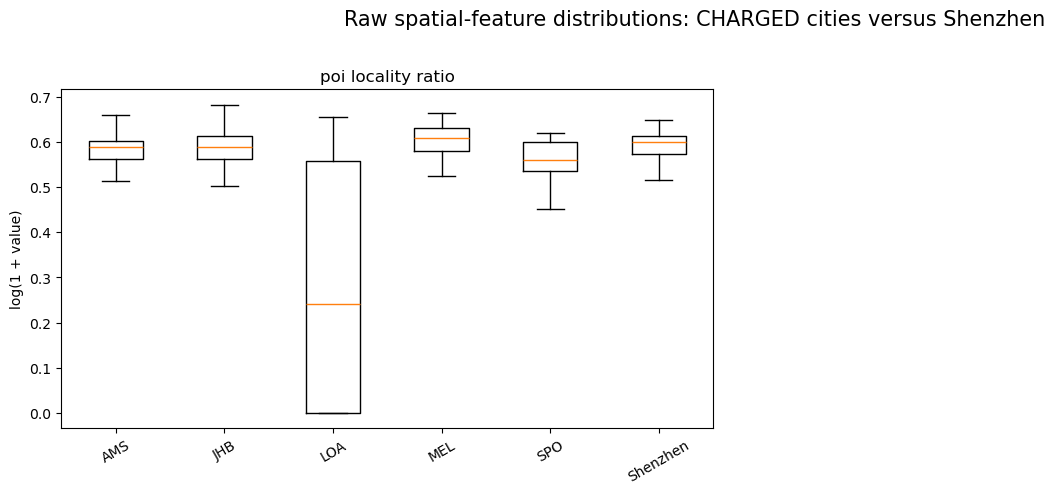

Saved feature-shift tables and figure.


In [28]:
# Prompt: Diagnose raw-feature distribution shift between each CHARGED city and UrbanEV Shenzhen.

from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import ks_2samp, wasserstein_distance

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

charged_shift_data = (
    enriched_spatial_modeling_data.copy()
)

shenzhen_shift_data = (
    urbanev_spatial_ranking_enriched.copy()
)

shared_columns = sorted(
    set(charged_shift_data.columns)
    .intersection(shenzhen_shift_data.columns)
)

raw_feature_candidates = [
    "total_poi_within_500m",
    "total_poi_within_1000m",
    "poi_locality_ratio",
    "population_3x3_sum",
    "built_surface_fraction_3x3",
    "total_chargers",
    "station_count",
    "log_total_chargers",
    "log_station_count",
]

shift_features = [
    feature_name
    for feature_name in raw_feature_candidates
    if feature_name in shared_columns
]

assert len(shift_features) > 0, (
    "No expected shared raw features were found. "
    "Inspect shared_columns."
)

print("Features used for distribution-shift diagnosis:")
print(shift_features)

def transform_for_shift_analysis(
    series,
    feature_name,
):
    numeric_series = pd.to_numeric(
        series,
        errors="coerce",
    )

    if (
        "poi" in feature_name
        or "population" in feature_name
        or feature_name in [
            "total_chargers",
            "station_count",
        ]
    ):
        return np.log1p(numeric_series)

    return numeric_series

distribution_shift_rows = []

for feature_name in shift_features:
    shenzhen_values = transform_for_shift_analysis(
        shenzhen_shift_data[feature_name],
        feature_name,
    ).dropna()

    for city_code in sorted(
        charged_shift_data[spatial_group_column].unique()
    ):
        city_values = transform_for_shift_analysis(
            charged_shift_data.loc[
                charged_shift_data[
                    spatial_group_column
                ] == city_code,
                feature_name,
            ],
            feature_name,
        ).dropna()

        ks_result = ks_2samp(
            city_values,
            shenzhen_values,
        )

        pooled_standard_deviation = np.sqrt(
            (
                city_values.var(ddof=1)
                + shenzhen_values.var(ddof=1)
            )
            / 2
        )

        if pooled_standard_deviation == 0:
            standardized_mean_difference = np.nan
        else:
            standardized_mean_difference = (
                shenzhen_values.mean()
                - city_values.mean()
            ) / pooled_standard_deviation

        external_within_city_range_percent = (
            (
                (
                    shenzhen_values >= city_values.min()
                )
                & (
                    shenzhen_values <= city_values.max()
                )
            )
            .mean()
            * 100
        )

        distribution_shift_rows.append(
            {
                "feature": feature_name,
                "transformation": (
                    "log1p"
                    if (
                        "poi" in feature_name
                        or "population" in feature_name
                        or feature_name
                        in [
                            "total_chargers",
                            "station_count",
                        ]
                    )
                    else "none"
                ),
                "reference_city": city_code,
                "reference_units": len(city_values),
                "shenzhen_units": len(shenzhen_values),
                "reference_median": city_values.median(),
                "shenzhen_median": shenzhen_values.median(),
                "standardized_mean_difference": (
                    standardized_mean_difference
                ),
                "wasserstein_distance": (
                    wasserstein_distance(
                        city_values,
                        shenzhen_values,
                    )
                ),
                "ks_statistic": ks_result.statistic,
                "ks_p_value": ks_result.pvalue,
                "shenzhen_values_within_city_range_percent": (
                    external_within_city_range_percent
                ),
            }
        )

distribution_shift_audit = pd.DataFrame(
    distribution_shift_rows
)

distribution_shift_summary = (
    distribution_shift_audit
    .groupby("feature", as_index=False)
    .agg(
        mean_ks_statistic=(
            "ks_statistic",
            "mean",
        ),
        maximum_ks_statistic=(
            "ks_statistic",
            "max",
        ),
        mean_absolute_standardized_difference=(
            "standardized_mean_difference",
            lambda values: values.abs().mean(),
        ),
        mean_range_overlap_percent=(
            "shenzhen_values_within_city_range_percent",
            "mean",
        ),
    )
    .sort_values(
        "mean_ks_statistic",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    distribution_shift_summary
)

display(
    distribution_shift_audit
    .sort_values(
        ["feature", "ks_statistic"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

distribution_shift_audit.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_shenzhen_raw_feature_shift_by_city.csv",
    index=False,
    encoding="utf-8-sig",
)

distribution_shift_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_shenzhen_raw_feature_shift_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

plot_data = []

for city_code in sorted(
    charged_shift_data[spatial_group_column].unique()
):
    city_subset = charged_shift_data.loc[
        charged_shift_data[
            spatial_group_column
        ] == city_code
    ].copy()

    city_subset["dataset_label"] = city_code

    plot_data.append(city_subset)

shenzhen_plot_subset = shenzhen_shift_data.copy()
shenzhen_plot_subset["dataset_label"] = "Shenzhen"

plot_data = pd.concat(
    plot_data + [shenzhen_plot_subset],
    ignore_index=True,
)

number_of_columns = 2
number_of_rows = math.ceil(
    len(shift_features) / number_of_columns
)

figure, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(
        14,
        4.8 * number_of_rows,
    ),
)

axes = np.array(axes).reshape(-1)

dataset_order = sorted(
    charged_shift_data[
        spatial_group_column
    ].unique()
) + ["Shenzhen"]

for axis, feature_name in zip(
    axes,
    shift_features,
):
    feature_plot_values = []

    for dataset_label in dataset_order:
        selected_values = transform_for_shift_analysis(
            plot_data.loc[
                plot_data["dataset_label"]
                == dataset_label,
                feature_name,
            ],
            feature_name,
        ).dropna()

        feature_plot_values.append(
            selected_values
        )

    axis.boxplot(
        feature_plot_values,
        tick_labels=dataset_order,
        showfliers=False,
    )

    axis.set_title(
        feature_name.replace("_", " ")
    )

    if (
        "poi" in feature_name
        or "population" in feature_name
        or feature_name
        in [
            "total_chargers",
            "station_count",
        ]
    ):
        axis.set_ylabel(
            "log(1 + value)"
        )
    else:
        axis.set_ylabel("value")

    axis.tick_params(
        axis="x",
        rotation=30,
    )

for axis in axes[len(shift_features):]:
    axis.set_visible(False)

figure.suptitle(
    "Raw spatial-feature distributions: "
    "CHARGED cities versus Shenzhen",
    fontsize=15,
    y=1.02,
)

figure.tight_layout()

figure.savefig(
    OUTPUT_FIGURES_DIR
    / "charged_shenzhen_raw_feature_distribution_shift.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved feature-shift tables and figure."
)

In [29]:
# Prompt: Inspect and harmonize differently named raw spatial features before the full CHARGED–Shenzhen shift analysis.

from pathlib import Path

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

feature_keywords = [
    "poi",
    "population",
    "built",
    "charger",
    "station",
    "capacity",
    "surface",
    "area",
]

charged_column_inventory = pd.DataFrame(
    {
        "dataset": "CHARGED",
        "column_name": charged_shift_data.columns,
    }
)

urbanev_column_inventory = pd.DataFrame(
    {
        "dataset": "UrbanEV_Shenzhen",
        "column_name": shenzhen_shift_data.columns,
    }
)

combined_column_inventory = pd.concat(
    [
        charged_column_inventory,
        urbanev_column_inventory,
    ],
    ignore_index=True,
)

relevant_column_inventory = (
    combined_column_inventory.loc[
        combined_column_inventory[
            "column_name"
        ].str.lower().apply(
            lambda column_name: any(
                keyword in column_name
                for keyword in feature_keywords
            )
        )
    ]
    .sort_values(
        ["dataset", "column_name"]
    )
    .reset_index(drop=True)
)

display(relevant_column_inventory)

relevant_column_inventory.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_urbanev_raw_feature_name_inventory.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Saved raw-feature name inventory."
)

,dataset,column_name
0,CHARGED,built_surface_fraction_3x3_percentile
1,CHARGED,poi_1000m_percentile
2,CHARGED,poi_500m_percentile
3,CHARGED,poi_locality_ratio
4,CHARGED,population_3x3_sum_percentile
5,UrbanEV_Shenzhen,area
6,UrbanEV_Shenzhen,built_surface_fraction_3x3
7,UrbanEV_Shenzhen,built_surface_fraction_3x3_percentile
8,UrbanEV_Shenzhen,mean_daily_duration_per_charger
9,UrbanEV_Shenzhen,poi_1000m_percentile


Saved raw-feature name inventory.


In [30]:
# Prompt: Locate the intermediate CHARGED raw spatial-feature files needed for full distribution-shift diagnosis.

from pathlib import Path

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("data")

required_file_patterns = [
    "charged_grid_total_poi_features.csv",
    "charged_grid_ghsl_features.csv",
    "charged_grid_long_term_demand_potential.csv",
]

located_files_rows = []

for file_pattern in required_file_patterns:
    matching_files = sorted(
        DATA_DIR.rglob(file_pattern)
    )

    if len(matching_files) == 0:
        located_files_rows.append(
            {
                "expected_file": file_pattern,
                "status": "not_found",
                "path": None,
            }
        )

    else:
        for matching_file in matching_files:
            located_files_rows.append(
                {
                    "expected_file": file_pattern,
                    "status": "found",
                    "path": str(matching_file),
                }
            )

located_feature_files = pd.DataFrame(
    located_files_rows
)

display(located_feature_files)

located_feature_files.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_intermediate_feature_file_locations.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "Saved intermediate-file location inventory."
)

,expected_file,status,path
0,charged_grid_total_poi_features.csv,not_found,None
1,charged_grid_ghsl_features.csv,not_found,None
2,charged_grid_long_term_demand_potential.csv,not_found,None


Saved intermediate-file location inventory.


In [31]:
# Prompt: Find the project root and list saved CHARGED grid, POI, and GHSL intermediate files.

from pathlib import Path

search_start_directories = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

file_inventory_rows = []

for search_directory in search_start_directories:
    if not search_directory.exists():
        continue

    matching_files = sorted(
        file_path
        for file_path in search_directory.rglob("*")
        if file_path.is_file()
        and (
            "charged" in file_path.name.lower()
            or "ghsl" in file_path.name.lower()
        )
        and (
            "grid" in file_path.name.lower()
            or "poi" in file_path.name.lower()
            or "ghsl" in file_path.name.lower()
        )
        and file_path.suffix.lower() in [
            ".csv",
            ".gz",
        ]
    )

    for matching_file in matching_files:
        file_inventory_rows.append(
            {
                "searched_from": str(search_directory),
                "file_name": matching_file.name,
                "full_path": str(matching_file),
            }
        )

project_feature_file_inventory = (
    pd.DataFrame(file_inventory_rows)
    .drop_duplicates(
        subset=["full_path"]
    )
    .sort_values("file_name")
    .reset_index(drop=True)
)

display(
    pd.DataFrame(
        {
            "current_working_directory": [
                str(Path.cwd())
            ]
        }
    )
)

display(project_feature_file_inventory)

print(
    "Matching files found:",
    len(project_feature_file_inventory),
)

,current_working_directory
0,F:\UrbanEV_Charging_Demand\notebooks


,searched_from,file_name,full_path
0,F:\UrbanEV_Charging_Demand,charged_grid_day_construction_audit.csv,F:\UrbanEV_Charging_Demand\outputs\tables\char...
1,F:\UrbanEV_Charging_Demand,charged_grid_day_modeling_base.csv.gz,F:\UrbanEV_Charging_Demand\data\processed\char...
2,F:\UrbanEV_Charging_Demand,charged_grid_day_portable_modeling.csv.gz,F:\UrbanEV_Charging_Demand\data\processed\char...
3,F:\UrbanEV_Charging_Demand,charged_grid_ghsl_features.csv,F:\UrbanEV_Charging_Demand\data\interim\charge...
4,F:\UrbanEV_Charging_Demand,charged_grid_long_term_demand_potential.csv,F:\UrbanEV_Charging_Demand\data\processed\char...
5,F:\UrbanEV_Charging_Demand,charged_grid_station_assignment_audit.csv,F:\UrbanEV_Charging_Demand\outputs\tables\char...
6,F:\UrbanEV_Charging_Demand,charged_grid_total_poi_features.csv,F:\UrbanEV_Charging_Demand\data\interim\charge...
7,F:\UrbanEV_Charging_Demand,charged_poi_feature_missingness_diagnosis.csv,F:\UrbanEV_Charging_Demand\outputs\tables\char...
8,F:\UrbanEV_Charging_Demand,charged_poi_grid_count_reconciliation.csv,F:\UrbanEV_Charging_Demand\outputs\tables\char...
9,F:\UrbanEV_Charging_Demand,charged_poi_semantic_group_distribution.csv,F:\UrbanEV_Charging_Demand\outputs\tables\char...


Matching files found: 21


In [32]:
# Prompt: Load the saved CHARGED raw grid-feature files from the project root and inspect their merge keys.

from pathlib import Path

PROJECT_DIR = Path.cwd().parent

charged_grid_poi_raw = pd.read_csv(
    PROJECT_DIR
    / "data"
    / "interim"
    / "charged_grid_total_poi_features.csv"
)

charged_grid_ghsl_raw = pd.read_csv(
    PROJECT_DIR
    / "data"
    / "interim"
    / "charged_grid_ghsl_features.csv"
)

charged_grid_demand_raw = pd.read_csv(
    PROJECT_DIR
    / "data"
    / "processed"
    / "charged_grid_long_term_demand_potential.csv"
)

charged_raw_source_schema = pd.DataFrame(
    [
        {
            "source_file": (
                "charged_grid_total_poi_features.csv"
            ),
            "rows": len(charged_grid_poi_raw),
            "columns": " | ".join(
                charged_grid_poi_raw.columns
            ),
        },
        {
            "source_file": (
                "charged_grid_ghsl_features.csv"
            ),
            "rows": len(charged_grid_ghsl_raw),
            "columns": " | ".join(
                charged_grid_ghsl_raw.columns
            ),
        },
        {
            "source_file": (
                "charged_grid_long_term_demand_potential.csv"
            ),
            "rows": len(charged_grid_demand_raw),
            "columns": " | ".join(
                charged_grid_demand_raw.columns
            ),
        },
    ]
)

display(charged_raw_source_schema)

print("POI source sample:")
display(charged_grid_poi_raw.head(3))

print("GHSL source sample:")
display(charged_grid_ghsl_raw.head(3))

print("Demand/capacity source sample:")
display(charged_grid_demand_raw.head(3))

,source_file,rows,columns
0,charged_grid_total_poi_features.csv,365,city_code | grid_id | total_poi_within_500m | ...
1,charged_grid_ghsl_features.csv,365,city_code | grid_id | population_3x3_sum | pop...
2,charged_grid_long_term_demand_potential.csv,365,city_code | city_name | country_name | grid_id...


POI source sample:


,city_code,grid_id,total_poi_within_500m,total_poi_within_1000m
0,AMS,AMS_32631_412_3871,18.000000,61.000000
1,AMS,AMS_32631_412_3872,10.000000,40.500000
2,AMS,AMS_32631_413_3867,145.833333,461.333333


GHSL source sample:


,city_code,grid_id,population_3x3_sum,population_3x3_mean,population_valid_cells,built_surface_3x3_sum,built_surface_3x3_mean,built_surface_valid_cells,built_surface_fraction_3x3
0,AMS,AMS_32631_412_3871,12607.278256,1400.808695,9,1406139.0,156237.666667,9,0.156238
1,AMS,AMS_32631_412_3872,14153.482490,1572.609166,9,1557592.0,173065.777778,9,0.173066
2,AMS,AMS_32631_413_3867,32159.158108,3573.239790,9,1713920.0,190435.555556,9,0.190436


Demand/capacity source sample:


,city_code,city_name,country_name,grid_id,observed_days,grid_total_chargers,grid_station_count,grid_longitude,grid_latitude,mean_daily_duration_per_charger,...,poi_healthcare_within_1000m,poi_healthcare_within_500m,poi_parking_mobility_within_1000m,poi_parking_mobility_within_500m,poi_public_services_within_1000m,poi_public_services_within_500m,poi_recreation_within_1000m,poi_recreation_within_500m,demand_potential_percentile,high_demand_potential
0,AMS,Amsterdam,Netherlands,AMS_32631_412_3871,183,7,4,4.751895,52.401074,101.739266,...,0.000000,0.0,15.25,5.750000,0.000000,0.000000,7.000000,0.750000,0.965517,1
1,AMS,Amsterdam,Netherlands,AMS_32631_412_3872,183,2,2,4.750452,52.415874,0.000000,...,0.000000,0.0,10.50,1.000000,1.000000,0.000000,4.500000,1.500000,0.045977,0
2,AMS,Amsterdam,Netherlands,AMS_32631_413_3867,183,8,6,4.773835,52.351405,16.821890,...,1.166667,0.0,70.50,23.166667,195.666667,84.166667,65.333333,13.666667,0.310345,0


Harmonized CHARGED units: 365
Shenzhen units: 275


,feature,mean_ks_statistic,maximum_ks_statistic,mean_absolute_standardized_difference,mean_range_overlap_percent
0,total_chargers,0.838988,1.000000,3.717236,22.327273
1,total_poi_within_1000m,0.708913,0.889298,1.995570,48.509091
2,population_3x3_sum,0.600560,0.862338,1.347170,64.218182
3,total_poi_within_500m,0.597208,0.808493,1.597288,54.036364
4,station_count,0.584559,0.742884,1.496827,66.036364
5,built_surface_fraction_3x3,0.521965,0.859798,1.250437,85.381818


,feature,transformation,reference_city,reference_units,shenzhen_units,reference_median,shenzhen_median,standardized_mean_difference,wasserstein_distance,ks_statistic,ks_p_value,shenzhen_within_city_range_percent
0,built_surface_fraction_3x3,none,SPO,27,275,0.389080,0.224209,-2.683760,0.159142,0.859798,1.511708e-20,37.090909
1,built_surface_fraction_3x3,none,LOA,158,275,0.334619,0.224209,-1.503306,0.098877,0.607986,3.306296e-35,98.545455
2,built_surface_fraction_3x3,none,JHB,35,275,0.302741,0.224209,-1.031545,0.068363,0.496104,1.530021e-07,94.545455
3,built_surface_fraction_3x3,none,MEL,58,275,0.284985,0.224209,-0.691881,0.049745,0.436991,8.379304e-09,99.636364
4,built_surface_fraction_3x3,none,AMS,87,275,0.193552,0.224209,0.341694,0.023586,0.208945,5.138260e-03,97.090909
5,population_3x3_sum,log1p,JHB,35,275,10.010410,11.506901,2.093491,1.520950,0.862338,8.249148e-26,70.545455
6,population_3x3_sum,log1p,MEL,58,275,9.999588,11.506901,1.888654,1.488228,0.744639,5.519470e-27,40.727273
7,population_3x3_sum,log1p,LOA,158,275,10.375223,11.506901,1.319677,1.192457,0.625478,2.067934e-37,66.181818
8,population_3x3_sum,log1p,AMS,87,275,10.483065,11.506901,1.283992,1.021599,0.551223,4.162714e-19,66.545455
9,population_3x3_sum,log1p,SPO,27,275,11.300808,11.506901,0.150036,0.305097,0.219125,1.606671e-01,77.090909


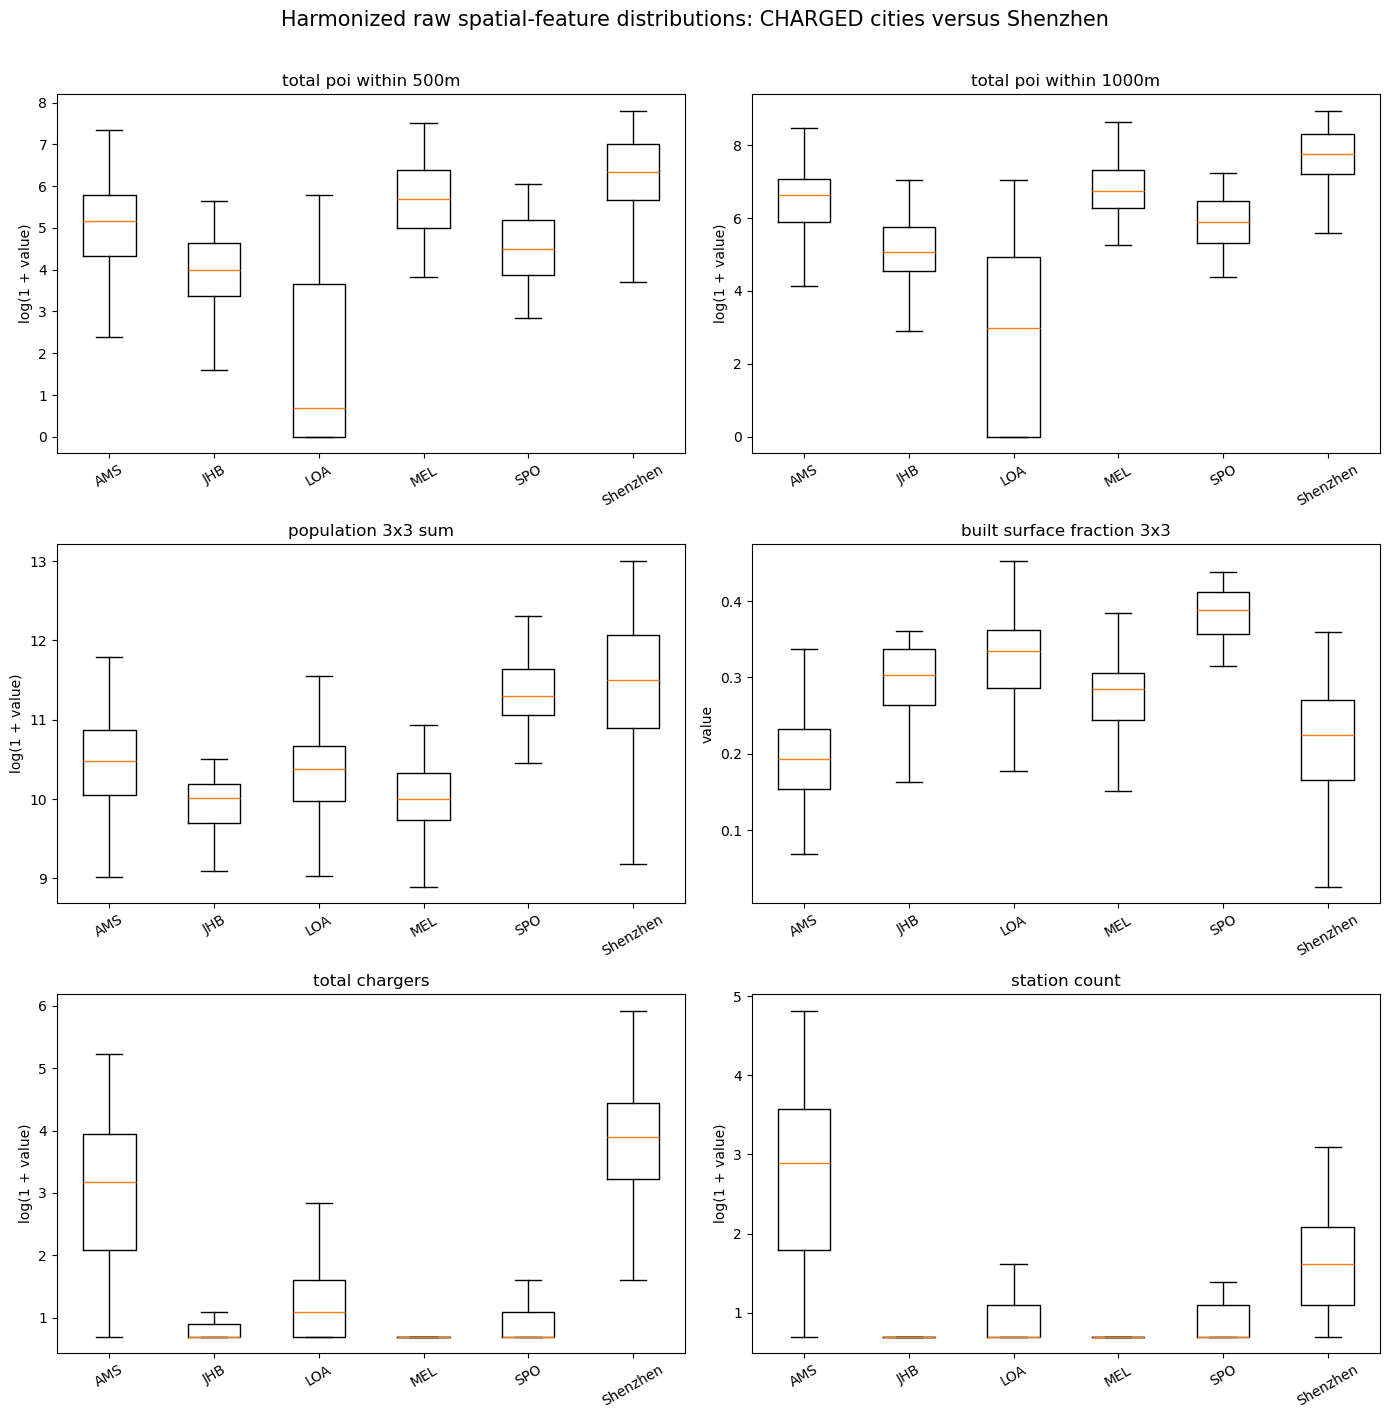

Saved complete raw-feature shift tables and figure.


In [33]:
# Prompt: Build harmonized raw spatial features and quantify CHARGED–Shenzhen distribution shift.

from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import ks_2samp, wasserstein_distance

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

charged_capacity_features = (
    charged_grid_demand_raw[
        [
            "city_code",
            "grid_id",
            "grid_total_chargers",
            "grid_station_count",
        ]
    ]
    .copy()
)

charged_raw_shift_features = (
    charged_capacity_features
    .merge(
        charged_grid_poi_raw,
        on=["city_code", "grid_id"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        charged_grid_ghsl_raw[
            [
                "city_code",
                "grid_id",
                "population_3x3_sum",
                "built_surface_fraction_3x3",
            ]
        ],
        on=["city_code", "grid_id"],
        how="inner",
        validate="one_to_one",
    )
)

assert len(charged_raw_shift_features) == 365

charged_raw_shift_features = (
    charged_raw_shift_features
    .rename(
        columns={
            "grid_total_chargers": "total_chargers",
            "grid_station_count": "station_count",
        }
    )
)

shenzhen_raw_shift_features = (
    shenzhen_shift_data[
        [
            "total_poi_within_500m",
            "total_poi_within_1000m",
            "population_3x3_sum",
            "built_surface_fraction_3x3",
            "total_chargers",
            "station_count",
        ]
    ]
    .copy()
)

harmonized_raw_features = [
    "total_poi_within_500m",
    "total_poi_within_1000m",
    "population_3x3_sum",
    "built_surface_fraction_3x3",
    "total_chargers",
    "station_count",
]

assert (
    charged_raw_shift_features[
        harmonized_raw_features
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    shenzhen_raw_shift_features[
        harmonized_raw_features
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print(
    "Harmonized CHARGED units:",
    len(charged_raw_shift_features),
)

print(
    "Shenzhen units:",
    len(shenzhen_raw_shift_features),
)

def shift_transformation(
    series,
    feature_name,
):
    numeric_series = pd.to_numeric(
        series,
        errors="coerce",
    )

    if feature_name == "built_surface_fraction_3x3":
        return numeric_series

    return np.log1p(numeric_series)

shift_rows = []

for feature_name in harmonized_raw_features:
    shenzhen_values = shift_transformation(
        shenzhen_raw_shift_features[feature_name],
        feature_name,
    ).dropna()

    for city_code in sorted(
        charged_raw_shift_features[
            "city_code"
        ].unique()
    ):
        city_values = shift_transformation(
            charged_raw_shift_features.loc[
                charged_raw_shift_features[
                    "city_code"
                ] == city_code,
                feature_name,
            ],
            feature_name,
        ).dropna()

        ks_result = ks_2samp(
            city_values,
            shenzhen_values,
        )

        pooled_standard_deviation = np.sqrt(
            (
                city_values.var(ddof=1)
                + shenzhen_values.var(ddof=1)
            )
            / 2
        )

        standardized_mean_difference = (
            (
                shenzhen_values.mean()
                - city_values.mean()
            )
            / pooled_standard_deviation
            if pooled_standard_deviation > 0
            else np.nan
        )

        shift_rows.append(
            {
                "feature": feature_name,
                "transformation": (
                    "none"
                    if feature_name
                    == "built_surface_fraction_3x3"
                    else "log1p"
                ),
                "reference_city": city_code,
                "reference_units": len(city_values),
                "shenzhen_units": len(shenzhen_values),
                "reference_median": city_values.median(),
                "shenzhen_median": shenzhen_values.median(),
                "standardized_mean_difference": (
                    standardized_mean_difference
                ),
                "wasserstein_distance": (
                    wasserstein_distance(
                        city_values,
                        shenzhen_values,
                    )
                ),
                "ks_statistic": ks_result.statistic,
                "ks_p_value": ks_result.pvalue,
                "shenzhen_within_city_range_percent": (
                    (
                        (
                            shenzhen_values
                            >= city_values.min()
                        )
                        & (
                            shenzhen_values
                            <= city_values.max()
                        )
                    )
                    .mean()
                    * 100
                ),
            }
        )

full_distribution_shift_by_city = pd.DataFrame(
    shift_rows
)

full_distribution_shift_summary = (
    full_distribution_shift_by_city
    .groupby("feature", as_index=False)
    .agg(
        mean_ks_statistic=(
            "ks_statistic",
            "mean",
        ),
        maximum_ks_statistic=(
            "ks_statistic",
            "max",
        ),
        mean_absolute_standardized_difference=(
            "standardized_mean_difference",
            lambda values: values.abs().mean(),
        ),
        mean_range_overlap_percent=(
            "shenzhen_within_city_range_percent",
            "mean",
        ),
    )
    .sort_values(
        "mean_ks_statistic",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(full_distribution_shift_summary)

display(
    full_distribution_shift_by_city
    .sort_values(
        ["feature", "ks_statistic"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

full_distribution_shift_by_city.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_shenzhen_full_raw_feature_shift_by_city.csv",
    index=False,
    encoding="utf-8-sig",
)

full_distribution_shift_summary.to_csv(
    OUTPUT_TABLES_DIR
    / "charged_shenzhen_full_raw_feature_shift_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

plot_frame_list = []

for city_code in sorted(
    charged_raw_shift_features[
        "city_code"
    ].unique()
):
    city_frame = charged_raw_shift_features.loc[
        charged_raw_shift_features[
            "city_code"
        ] == city_code
    ].copy()

    city_frame["dataset_label"] = city_code

    plot_frame_list.append(city_frame)

shenzhen_plot_frame = (
    shenzhen_raw_shift_features.copy()
)

shenzhen_plot_frame["dataset_label"] = "Shenzhen"

plot_frame = pd.concat(
    plot_frame_list + [shenzhen_plot_frame],
    ignore_index=True,
)

dataset_order = sorted(
    charged_raw_shift_features[
        "city_code"
    ].unique()
) + ["Shenzhen"]

figure, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14),
)

axes = axes.flatten()

for axis, feature_name in zip(
    axes,
    harmonized_raw_features,
):
    values_for_boxplot = [
        shift_transformation(
            plot_frame.loc[
                plot_frame["dataset_label"]
                == dataset_label,
                feature_name,
            ],
            feature_name,
        ).dropna()
        for dataset_label in dataset_order
    ]

    axis.boxplot(
        values_for_boxplot,
        tick_labels=dataset_order,
        showfliers=False,
    )

    axis.set_title(
        feature_name.replace("_", " ")
    )

    axis.set_ylabel(
        (
            "value"
            if feature_name
            == "built_surface_fraction_3x3"
            else "log(1 + value)"
        )
    )

    axis.tick_params(
        axis="x",
        rotation=30,
    )

figure.suptitle(
    "Harmonized raw spatial-feature distributions: "
    "CHARGED cities versus Shenzhen",
    fontsize=15,
    y=1.01,
)

figure.tight_layout()

figure.savefig(
    OUTPUT_FIGURES_DIR
    / "charged_shenzhen_harmonized_raw_feature_shift.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved complete raw-feature shift tables and figure."
)

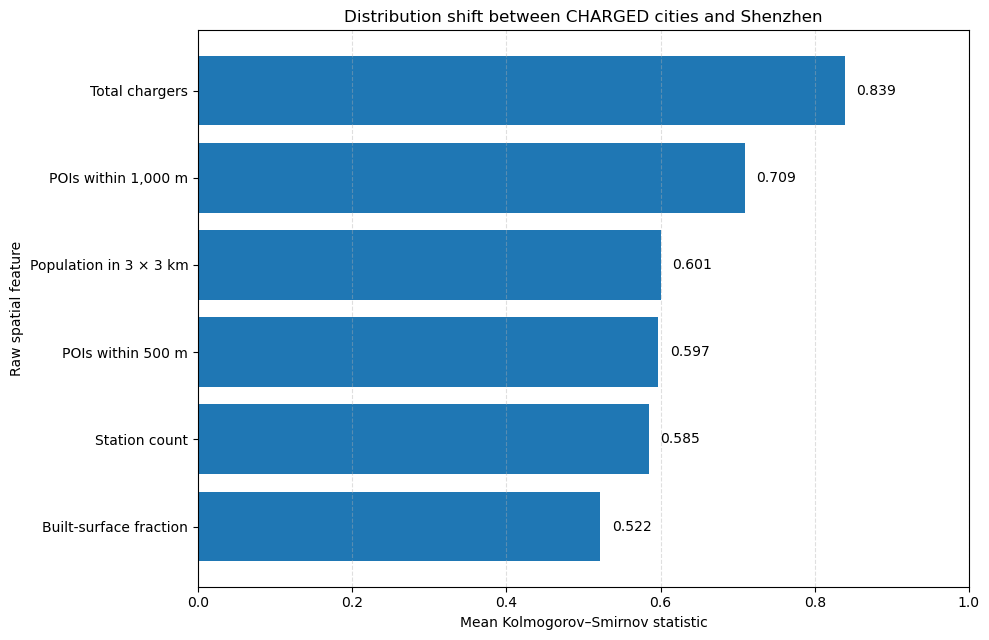

Saved publication-ready distribution-shift bar chart.


In [34]:
# Prompt: Create a publication-ready bar chart showing the magnitude of raw-feature distribution shift from CHARGED cities to Shenzhen.

from pathlib import Path

import matplotlib.pyplot as plt

OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

bar_chart_data = (
    full_distribution_shift_summary
    .sort_values(
        "mean_ks_statistic",
        ascending=True,
    )
    .copy()
)

feature_display_names = {
    "total_chargers": "Total chargers",
    "total_poi_within_1000m": "POIs within 1,000 m",
    "population_3x3_sum": "Population in 3 × 3 km",
    "total_poi_within_500m": "POIs within 500 m",
    "station_count": "Station count",
    "built_surface_fraction_3x3": (
        "Built-surface fraction"
    ),
}

bar_chart_data["feature_label"] = (
    bar_chart_data["feature"]
    .map(feature_display_names)
    .fillna(
        bar_chart_data["feature"]
    )
)

figure, axis = plt.subplots(
    figsize=(10, 6.5),
)

bars = axis.barh(
    bar_chart_data["feature_label"],
    bar_chart_data["mean_ks_statistic"],
)

axis.set_xlabel(
    "Mean Kolmogorov–Smirnov statistic"
)

axis.set_ylabel(
    "Raw spatial feature"
)

axis.set_title(
    "Distribution shift between CHARGED cities and Shenzhen"
)

axis.set_xlim(0, 1)

axis.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

for bar, value in zip(
    bars,
    bar_chart_data["mean_ks_statistic"],
):
    axis.text(
        value + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
    )

figure.tight_layout()

figure.savefig(
    OUTPUT_FIGURES_DIR
    / "charged_shenzhen_distribution_shift_bar_chart.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved publication-ready distribution-shift bar chart."
)